In [ ]:
#full_df is 

In [7]:
pip install pandas numpy matplotlib scipy statsmodels


Note: you may need to restart the kernel to use updated packages.


In [8]:
import os

# Point to your local Downloads folder instead of the Colab Drive
BASE_PATH = os.path.expanduser("~/Downloads/MsC Thesis")

# Check if the folder exists and change to it
if not os.path.exists(BASE_PATH):
    print(f"Error: Could not find folder at {BASE_PATH}. Make sure it is saved there.")
else:
    print("Files in folder:", os.listdir(BASE_PATH))
    os.chdir(BASE_PATH)
    print("Current Working Directory:", os.getcwd())



Files in folder: ['btc_tail_dependence_plots_hill.png', 'thesis_all_oi_weighted_funding.csv', 'btc.csv', 'Aggregated OI .png', 'btc_tail_dependence_plots.png', 'thesis_custom_vw_funding.csv', 'thesis_full_df_backup_final.csv', 'Metric Comparison - BNB Chain-2.csv', 'thesis_btc_oi_weighted_fundingrate.csv', 'Chart_All_Coins_Funding.png', 'MsC_Thesis_Siebe-7.pdf', 'thesis_oi_numerator.csv', 'thesis_exchange_funding_rates.csv', 'btc_basic_plots.png', 'Chart_Systemic_Stress.png', 'Metric Comparison - Ethereum-2.csv', 'sol-usd-max.csv', 'metric-comparison-solana-3.csv', 'Metric Comparison - Ethereum-3.csv', 'Validation_OI_Numerator.png', 'eth_security_distribution.png']
Current Working Directory: /Users/iphonevansiebe/Downloads/MsC Thesis


In [9]:
pip install defillama-sdk

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install coinmetrics-api-client

Note: you may need to restart the kernel to use updated packages.


In [11]:
from defillama_sdk import DefiLlama

client = DefiLlama()
protocols = client.tvl.getProtocols()
result = client.tvl.getHistoricalChainTvl()
#result in Unix Timestamps for all combined chains

In [12]:
from coinmetrics.api_client import CoinMetricsClient
import os

# or to use community API:
client = CoinMetricsClient()

In [13]:
from datetime import datetime

timestamp = 1506470400
readable_date = datetime.fromtimestamp(timestamp)

print(readable_date)
# Output: 2017-09-27 00:00:00

2017-09-27 02:00:00


In [14]:

from datetime import datetime

# 1. Convert the SDK result to a DataFrame
#df = pd.DataFrame(result_sol)

# 2. Convert Unix timestamps to readable dates
#df['date'] = pd.to_datetime(df['date'], unit='s')

# 3. Set the date as the index (crucial for time-series analysis)
#df.set_index('date', inplace=True)

In [15]:
import pandas as pd
import numpy as np
import requests
import io

def select_market_cap(df, ticker):
    cur = f"{ticker}_CapMrktCurUSD"
    est = f"{ticker}_CapMrktEstUSD"

    if cur in df.columns and not df[cur].isna().all():
        return df[cur]

    if est in df.columns and not df[est].isna().all():
        print(f"[INFO] Using EstUSD fallback for {ticker}")
        return df[est]

    print(f"[WARNING] No usable market cap for {ticker}")
    return np.nan

base_url = "https://raw.githubusercontent.com/coinmetrics/data/master/csv"
tickers = ['btc', 'eth', 'xrp', 'bnb', 'sol']

# Columns required for thesis
REQUIRED_COLUMNS = [
    "PriceUSD",          # Returns
    "CapMrktCurUSD",     # Market Cap (Size)
    "CapMVRVCur",        # MVRV (Valuation)
    "CapMrktEstUSD",      # 2nd marketcap
    "AdrActCnt",         # Network Activity
    "FlowInExUSD",       # Exchange Flows
    "FlowOutExUSD",      # Exchange Flows
    "HashRate" ,          # Security / Mining
    "volume_reported_spot_usd_1d" #only needed for btc
]

data_store = {}

print("Starting download...\n")

for ticker in tickers:
    url = f"{base_url}/{ticker}.csv"

    try:
        response = requests.get(url)

        if response.status_code == 200:
            df_coin = pd.read_csv(io.StringIO(response.content.decode('utf-8')))

            if 'time' in df_coin.columns:
                df_coin['time'] = pd.to_datetime(df_coin['time'].str[:10]) # Optional: keep just the date part if needed
                df_coin.set_index('time', inplace=True)

            # --- NEW CODE: Identify missing columns ---
            missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_coin.columns]
            if missing_cols:
                print(f"[MISSING] {ticker.upper()} is missing: {missing_cols}")
            # ----------------------------------------

            # Keep only columns that actually exist
            available_cols = [c for c in REQUIRED_COLUMNS if c in df_coin.columns]
            df_coin = df_coin[available_cols].copy()

            # Rename immediately → prevents later confusion
            df_coin.columns = [f"{ticker}_{c}" for c in df_coin.columns]

            data_store[ticker] = df_coin
            print(f"[SUCCESS] {ticker.upper()}: {len(df_coin)} rows, {len(available_cols)} columns.\n")

        else:
            print(f"[ERROR] Missing file for {ticker.upper()}. HTTP Status: {response.status_code}\n")

    except Exception as e:
        print(f"[ERROR] Failed {ticker.upper()}: {e}\n")

# Merge into master dataframe
if data_store:
    full_df = pd.concat(data_store.values(), axis=1)
    print("Merged dataset shape:", full_df.shape)
else:
    print("No data was downloaded.")

Starting download...

[SUCCESS] BTC: 6300 rows, 9 columns.

[SUCCESS] ETH: 3901 rows, 9 columns.

[MISSING] XRP is missing: ['FlowInExUSD', 'FlowOutExUSD', 'HashRate']
[SUCCESS] XRP: 4841 rows, 6 columns.

[MISSING] BNB is missing: ['FlowInExUSD', 'FlowOutExUSD', 'HashRate']
[SUCCESS] BNB: 3195 rows, 6 columns.

[MISSING] SOL is missing: ['PriceUSD', 'CapMrktCurUSD', 'CapMVRVCur', 'AdrActCnt', 'FlowInExUSD', 'FlowOutExUSD', 'HashRate']
[SUCCESS] SOL: 2184 rows, 2 columns.

Merged dataset shape: (6300, 32)


In [16]:
import pandas as pd
import numpy as np
import requests
import io

print("--- FETCHING STABLECOIN DATA FOR M_fiat ---")

# 1. Fetch USDT and USDC from CoinMetrics GitHub
stablecoins = ['usdt', 'usdc']
stable_df_list = []

for coin in stablecoins:
    url = f"https://raw.githubusercontent.com/coinmetrics/data/master/csv/{coin}.csv"
    response = requests.get(url)

    if response.status_code == 200:
        # Load CSV into pandas
        temp_df = pd.read_csv(io.StringIO(response.content.decode('utf-8')))

        # Clean dates
        temp_df['time'] = pd.to_datetime(temp_df['time'].str[:10])
        temp_df.set_index('time', inplace=True)

        # We only need the Market Cap column
        if 'CapMrktCurUSD' in temp_df.columns:
            temp_df = temp_df[['CapMrktCurUSD']].rename(columns={'CapMrktCurUSD': f'{coin}_MC'})
            stable_df_list.append(temp_df)
            print(f"Successfully fetched {coin.upper()} Market Cap.")
    else:
        print(f"Failed to fetch {coin.upper()}")

# 2. Combine and Calculate Total Stablecoin Market Cap
if len(stable_df_list) == 2:
    # Merge USDT and USDC
    df_stables = stable_df_list[0].join(stable_df_list[1], how='outer').ffill()

    # Total Fiat Liquidity (USDT + USDC Market Cap)
    df_stables['Total_Stable_MC'] = df_stables['usdt_MC'] + df_stables['usdc_MC']

    # Calculate M_fiat: The daily log-growth of Fiat Liquidity
    df_stables['M_fiat'] = np.log(df_stables['Total_Stable_MC']).diff()

    # Merge into your Master DataFrame (Assuming 'full_df' exists)
    if 'full_df' in locals():
        full_df = full_df.join(df_stables[['usdt_MC', 'usdc_MC', 'M_fiat']], how='left')
        print("M_fiat successfully merged into full_df.")
else:
    print("Could not build M_fiat due to missing stablecoin data.")


print("\n--- CONSTRUCTING FINAL 5-VARIABLE MARKET VECTOR ---")

if 'full_df' in locals():
    # 1. M_vol (Volatility: 30-day rolling std dev of BTC returns)
    if 'btc_PriceUSD' in full_df.columns:
        full_df['btc_ret'] = np.log(full_df['btc_PriceUSD']).diff()
        full_df['M_vol'] = full_df['btc_ret'].rolling(window=30).std() * np.sqrt(365) #BVOL index calculations (.BVOL: Annualized Historical Volatility Index)

        #OPTIONAL: Scale by 100 to match the traditional index format (e.g., 65.4 instead of 0.654)
        full_df["M_vol"] = full_df["M_vol"] * 100



    # 2. M_trend (Macro Trend: 90-day rolling mean of BTC returns)
    if 'btc_ret' in full_df.columns:
        full_df['M_trend'] = full_df['btc_ret'].rolling(window=90).mean()

    # 3. M_fund (Leverage Cost / Liquidity Spread)
    # Note: Assumes you merged this earlier from CoinGlass
    if 'M_fund' not in full_df.columns:
        print("Reminder: M_fund (BTC Funding Rate) needs to be merged.")

    # 4. M_volu (Market Friction/Activity: Log of BTC Spot Volume)
    if 'btc_volume_reported_spot_usd_1d' in full_df.columns:
        # Replace 0s with NaNs to avoid log(0) issues, though volume is rarely 0
        full_df['btc_vol_clean'] = full_df['btc_volume_reported_spot_usd_1d'].replace(0, np.nan)
        full_df['M_volu'] = np.log(full_df['btc_vol_clean'])

    # Final Check of the Vector for the thesis window
    M_vector_cols = ['M_vol', 'M_trend', 'M_fund', 'M_fiat', 'M_volu']

    # Only print columns that exist
    existing_cols = [c for c in M_vector_cols if c in full_df.columns]

    thesis_preview = full_df.loc['2020-01-01':'2025-12-31']

    print("Missing M_vol:", full_df["M_vol"].isna().mean())

    print("\nPreview of the Extended Market Vector (M_t):")
    print(thesis_preview[existing_cols].head())

--- FETCHING STABLECOIN DATA FOR M_fiat ---
Successfully fetched USDT Market Cap.
Successfully fetched USDC Market Cap.
M_fiat successfully merged into full_df.

--- CONSTRUCTING FINAL 5-VARIABLE MARKET VECTOR ---
Reminder: M_fund (BTC Funding Rate) needs to be merged.
Missing M_vol: 0.09396825396825396

Preview of the Extended Market Vector (M_t):
                M_vol   M_trend    M_fiat     M_volu
time                                                
2020-01-01  48.806759 -0.001564  0.000552  20.666765
2020-01-02  49.993737 -0.001796  0.000834  21.061118
2020-01-03  53.155621 -0.001189  0.001133  21.679431
2020-01-04  52.379727 -0.000748  0.000239  20.991821
2020-01-05  51.990729 -0.001258  0.000141  21.067071


In [17]:
# ==========================================
# FILTER SAMPLE PERIOD (Thesis Window)
# ==========================================

start_date = '2020-01-01'
end_date   = '2025-12-31'

# Ensure index is sorted (VERY important)
full_df = full_df.sort_index()

# Filter by date
full_df = full_df.loc[start_date:end_date].copy()


for t in tickers:
    full_df[f"{t}_MC"] = select_market_cap(full_df, t)



print("CurUSD missing:", full_df["bnb_CapMrktCurUSD"].isna().mean())
print("EstUSD missing:", full_df["bnb_CapMrktEstUSD"].isna().mean())
print("Unified MC missing:", full_df["bnb_MC"].isna().mean())


print("Filtered dataset shape:", full_df.shape)
print("Sample period:", full_df.index.min(), "→", full_df.index.max())

print("\nMissing values overview:")
print(full_df.isna().mean().sort_values(ascending=False).head(100))



[INFO] Using EstUSD fallback for bnb
[INFO] Using EstUSD fallback for sol
CurUSD missing: 1.0
EstUSD missing: 0.0
Unified MC missing: 0.0
Filtered dataset shape: (2192, 45)
Sample period: 2020-01-01 00:00:00 → 2025-12-31 00:00:00

Missing values overview:
bnb_CapMrktCurUSD                  1.000000
bnb_CapMVRVCur                     1.000000
bnb_AdrActCnt                      1.000000
eth_HashRate                       0.549270
sol_MC                             0.046077
sol_CapMrktEstUSD                  0.046077
sol_volume_reported_spot_usd_1d    0.046077
usdc_MC                            0.000000
bnb_CapMrktEstUSD                  0.000000
bnb_volume_reported_spot_usd_1d    0.000000
usdt_MC                            0.000000
M_fiat                             0.000000
xrp_volume_reported_spot_usd_1d    0.000000
btc_ret                            0.000000
M_vol                              0.000000
M_trend                            0.000000
btc_vol_clean                      0.000

In [18]:
#full_df['bnb_CapMrktEstUSD']
 # august 11



In [19]:
import pandas as pd
import requests

def get_defillama_tvl(tickers):
    """
    Fetches historical TVL data from DefiLlama for specified assets.
    """
    # Mapping tickers to DefiLlama slugs
    llama_slugs = {
        'eth': 'ethereum',
        'bnb': 'bsc',
        'sol': 'solana'
    }

    tvl_store = {}
    print("--- FETCHING DEFILLAMA TVL ---")

    for ticker in tickers:
        slug = llama_slugs.get(ticker.lower())
        if not slug:
            continue

        try:
            # API endpoint for historical chain TVL
            url = f"https://api.llama.fi/v2/historicalChainTvl/{slug}"
            resp = requests.get(url).json()

            # Convert to DataFrame
            df_tvl = pd.DataFrame(resp)

            # Convert Unix timestamp to datetime
            df_tvl['date'] = pd.to_datetime(df_tvl['date'], unit='s')
            df_tvl.set_index('date', inplace=True)

            # Rename column to include ticker for merging
            tvl_store[ticker] = df_tvl['tvl'].rename(f"{ticker.lower()}_TVL")
            print(f"   - Successfully loaded TVL for {ticker.upper()}")

        except Exception as e:
            print(f"   - Failed to load {ticker.upper()}: {e}")

    # Combine all individual TVL series into one DataFrame
    if tvl_store:
        return pd.concat(tvl_store.values(), axis=1).sort_index()
    else:
        return pd.DataFrame()

# --- EXECUTION ---
# Use the tickers defined in your proposal
my_tickers = ['eth', 'bnb', 'sol']
tvl_data = get_defillama_tvl(my_tickers)

# Display the latest entries
print("\n--- DEFILLAMA DATA READY ---")
print(tvl_data.tail())


--- FETCHING DEFILLAMA TVL ---
   - Successfully loaded TVL for ETH
   - Successfully loaded TVL for BNB
   - Successfully loaded TVL for SOL

--- DEFILLAMA DATA READY ---
                eth_TVL       bnb_TVL       sol_TVL
date                                               
2026-03-31  52491954265  5.349347e+09  6.163871e+09
2026-04-01  53985426296  5.408053e+09  6.339824e+09
2026-04-02  54108117557  5.380163e+09  5.375596e+09
2026-04-03  52661710995  5.287512e+09  5.450420e+09
2026-04-04  52661710995  5.287512e+09  5.450420e+09


In [20]:
import pandas as pd
import numpy as np

print("\n--- INTEGRATING LOCAL STAKING CSV (TVS) ---")

try:
    # 1. Load the new CSV
    # We must specify sep=';' and decimal=',' to correctly parse the European format
    staking_csv = pd.read_csv('Metric Comparison - Ethereum-3.csv', sep=';', decimal=',')

    # 2. Clean and format the datetime
    staking_csv['time'] = pd.to_datetime(staking_csv['DateTime']).dt.normalize()

    # 3. Extract the Native Staked ETH (Purest measure of network security)
    staking_csv['eth_staked_native'] = staking_csv['Ethereum - Total Staked (Native)']

    # Clean up and set index for perfect merging
    staking_csv = staking_csv[['time', 'eth_staked_native']].drop_duplicates(subset=['time'])
    staking_csv.set_index('time', inplace=True)

    # 4. Merge into full_df
    # Drop the column if it already exists in your notebook memory to prevent overlap errors
    if 'eth_staked_native' in full_df.columns:
        full_df.drop(columns=['eth_staked_native'], inplace=True)

    full_df = full_df.join(staking_csv, how='left')

    # 5. Calculate Log Returns (Growth) for both metrics
    eth_hash_growth = np.log(full_df['eth_HashRate']).diff()
    eth_staked_growth = np.log(full_df['eth_staked_native']).diff()

    # 6. SPLICE THEM: Build the continuous Security Factor
    full_df['eth_fac_security'] = eth_hash_growth.fillna(eth_staked_growth)

    # 7. Clean up temporary columns to keep full_df pristine
    full_df.drop(columns=['eth_staked_native'], inplace=True, errors='ignore')

    print("SUCCESS: Local CSV integrated! 'eth_fac_security' perfectly spliced using Native Staked ETH.")
    print(f"Total valid security rows: {full_df['eth_fac_security'].notna().sum()}")

except FileNotFoundError:
    print("[Error] Could not find 'Metric Comparison - Ethereum-3.csv'. Make sure it is in the same folder as this notebook.")
except Exception as e:
    print(f"[Error] Something went wrong: {e}")


--- INTEGRATING LOCAL STAKING CSV (TVS) ---
SUCCESS: Local CSV integrated! 'eth_fac_security' perfectly spliced using Native Staked ETH.
Total valid security rows: 1991



--- DESCRIPTIVE STATISTICS: PRE-MERGE VS POST-MERGE SECURITY GROWTH ---

Table 1: Summary Statistics of Ethereum Security Proxy (eth_fac_security)
---------------------------------------------------------------------------
       Pre-Merge (PoW Hash Rate)  Post-Merge (PoS Staking)
count                  987.00000                1004.00000
mean                     0.00179                   0.00063
std                      0.02025                   0.00210
min                     -0.05998                  -0.01488
25%                     -0.01129                  -0.00021
50%                      0.00271                   0.00056
75%                      0.01581                   0.00133
max                      0.05378                   0.01964
---------------------------------------------------------------------------


/var/folders/rl/g22y5pfj343_42448f60p78w0000gn/T/ipykernel_84590/1887164817.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Era', y='Security Growth (Log Return)',


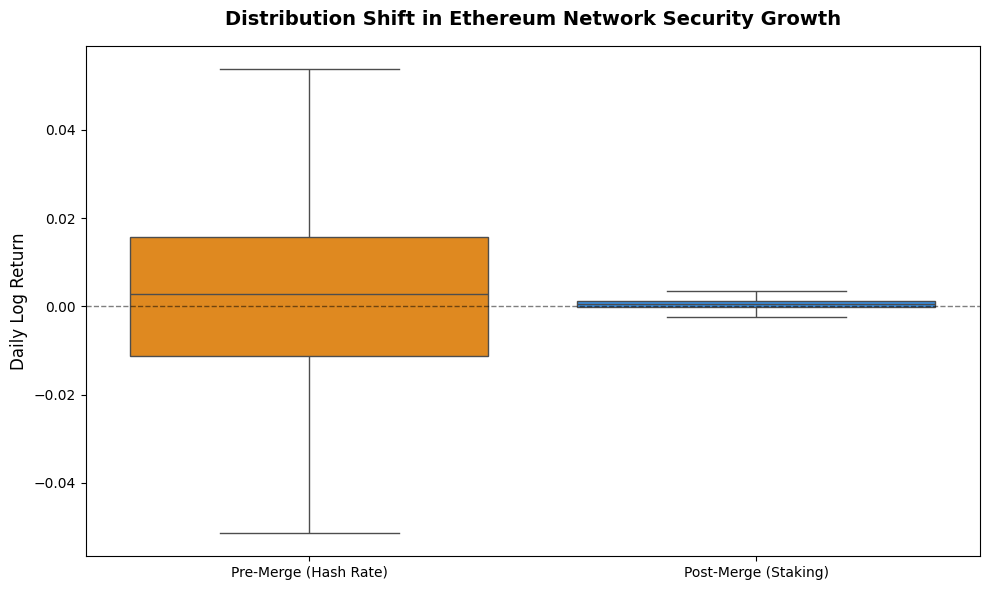


SUCCESS: Summary table generated and 'eth_security_distribution.png' saved!


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- DESCRIPTIVE STATISTICS: PRE-MERGE VS POST-MERGE SECURITY GROWTH ---")

# 1. Define the exact date of The Merge
merge_date = '2022-09-15'

# 2. Split the data into two eras
pre_merge = full_df.loc[full_df.index < merge_date, 'eth_fac_security'].dropna()
post_merge = full_df.loc[full_df.index >= merge_date, 'eth_fac_security'].dropna()

# 3. Generate the summary table
desc_pre = pre_merge.describe().rename('Pre-Merge (PoW Hash Rate)')
desc_post = post_merge.describe().rename('Post-Merge (PoS Staking)')

# Combine and format beautifully
comparison_table = pd.concat([desc_pre, desc_post], axis=1)
print("\nTable 1: Summary Statistics of Ethereum Security Proxy (eth_fac_security)")
print("-" * 75)
print(comparison_table.round(5)) # Rounding to 5 decimals for clean percentages
print("-" * 75)

# ==========================================
# 4. THESIS VISUALIZATION: THE BOXPLOT
# ==========================================
# A boxplot is the academically standard way to show shifts in variance
plt.figure(figsize=(10, 6))

# Prepare data for Seaborn
plot_data = pd.DataFrame({
    'Era': ['Pre-Merge (Hash Rate)'] * len(pre_merge) + ['Post-Merge (Staking)'] * len(post_merge),
    'Security Growth (Log Return)': pd.concat([pre_merge, post_merge])
})

# Create a clean boxplot
sns.boxplot(data=plot_data, x='Era', y='Security Growth (Log Return)',
            palette=['darkorange', 'dodgerblue'], showfliers=False) # Hiding extreme outliers for scale

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Distribution Shift in Ethereum Network Security Growth', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Daily Log Return', fontsize=12)
plt.xlabel('')

plt.tight_layout()
plt.savefig('eth_security_distribution.png', dpi=300)
plt.show()

print("\nSUCCESS: Summary table generated and 'eth_security_distribution.png' saved!")

In [22]:
# ==========================================
# FILTER TVL BY THESIS DATES + MERGE WITH full_df
# ==========================================

import numpy as np

start_date = "2020-01-01"
end_date   = "2025-12-31"

# 1) Filter TVL to thesis window
tvl_data = tvl_data.sort_index()
tvl_data = tvl_data.loc[start_date:end_date].copy()

print("TVL filtered shape:", tvl_data.shape)
print("TVL sample:", tvl_data.index.min(), "→", tvl_data.index.max())

# 2) Align to full_df daily index
# DefiLlama is daily but may have missing days; we reindex to full_df and forward-fill.
tvl_data = tvl_data.reindex(full_df.index)

# Forward-fill within the sample (TVL is a state variable; ffill is standard)
tvl_data = tvl_data.ffill()

# 3) Merge into full_df
full_df = full_df.join(tvl_data, how="left")

print("Merged full_df shape:", full_df.shape)
print("Missing TVL rates:")
for c in ["eth_TVL", "bnb_TVL", "sol_TVL"]:
    if c in full_df.columns:
        full_df[c.replace("_TVL", "_tvl_growth")] = np.log(full_df[c]).diff()

for c in ["eth_TVL", "bnb_TVL", "sol_TVL"]:
    if c in full_df.columns:
        print(c, "→", full_df[c].isna().mean())

TVL filtered shape: (2192, 3)
TVL sample: 2020-01-01 00:00:00 → 2025-12-31 00:00:00
Merged full_df shape: (2192, 49)
Missing TVL rates:
eth_TVL → 0.0
bnb_TVL → 0.1386861313868613
sol_TVL → 0.20164233576642335


In [23]:
# 1. Valuation for natively tracked ledgers (BTC, ETH, XRP)
for t in ['btc', 'eth', 'xrp']:
    if f'{t}_CapMVRVCur' in full_df.columns:
        # MVRV - 1 (Centers it at 0)
        full_df[f'{t}_fac_val'] = full_df[f'{t}_CapMVRVCur'] - 1

# 2. Valuation for DeFi Smart Contract Platforms (SOL, BNB)
for t in ['sol', 'bnb']:
    if f'{t}_MC' in full_df.columns and f'{t}_TVL' in full_df.columns:
        # Market Cap / TVL (The Market-to-Book proxy)
        full_df[f'{t}_fac_val'] = full_df[f'{t}_MC'] / full_df[f'{t}_TVL']

In [24]:
import pandas as pd
import numpy as np

def integrate_sol_market_data(full_df, filepath, overwrite=True):

    print("\n--- Integrating SOL Market Data ---")

    sol_df = pd.read_csv(filepath)

    # Parse snapped_at robustly + normalise to date (no time/tz)
    sol_df["snapped_at"] = pd.to_datetime(sol_df["snapped_at"], utc=True, errors="coerce")
    sol_df = sol_df.dropna(subset=["snapped_at"])
    sol_df["date"] = sol_df["snapped_at"].dt.tz_convert(None).dt.normalize()
    sol_df = sol_df.set_index("date").sort_index()

    # Keep & rename
    sol_df = sol_df[["price", "market_cap"]].copy()
    sol_df = sol_df.rename(columns={"price": "sol_PriceUSD", "market_cap": "sol_MC"})

    # Make sure full_df index is also normalised daily
    full_df = full_df.copy()
    full_df.index = pd.to_datetime(full_df.index).normalize()

    # Deduplicate SOL dates if needed (keep last)
    sol_df = sol_df[~sol_df.index.duplicated(keep="last")]

    # Align to full_df dates and forward-fill
    sol_df = sol_df.reindex(full_df.index).ffill()

    # Handle overlaps
    overlap_cols = [c for c in sol_df.columns if c in full_df.columns]
    if overlap_cols:
        if overwrite:
            full_df = full_df.drop(columns=overlap_cols)
            print(f"[INFO] Dropped existing columns before merge: {overlap_cols}")
        else:
            raise ValueError(f"Overlapping columns in full_df: {overlap_cols}")

    # Merge + compute log returns
    full_df = full_df.join(sol_df, how="left")
    full_df["sol_ret"] = np.log(full_df["sol_PriceUSD"]).diff()

    print("SOL integration complete.")
    print("Missing SOL price:", full_df["sol_PriceUSD"].isna().mean())
    print("Missing SOL MC:", full_df["sol_MC"].isna().mean())
    print("SOL date range in file:", sol_df.dropna().index.min(), "→", sol_df.dropna().index.max())

    return full_df

In [25]:
full_df = integrate_sol_market_data(full_df, "sol-usd-max.csv", overwrite=True)
#full_df[["sol_PriceUSD", "sol_ret", "sol_MC"]].tail()


--- Integrating SOL Market Data ---
[INFO] Dropped existing columns before merge: ['sol_MC']
SOL integration complete.
Missing SOL price: 0.04607664233576642
Missing SOL MC: 0.04607664233576642
SOL date range in file: 2020-04-11 00:00:00 → 2025-12-31 00:00:00


In [26]:
tmp = pd.read_csv("sol-usd-max.csv")
tmp["snapped_at"] = pd.to_datetime(tmp["snapped_at"], errors="coerce")
print(tmp["snapped_at"].min(), tmp["snapped_at"].max(), len(tmp))

2020-04-11 00:00:00+00:00 2026-02-19 00:00:00+00:00 2141


In [27]:
sol_start = full_df["sol_PriceUSD"].dropna().index.min()
print("SOL start:", sol_start)

# truncate entire dataset to common window
full_df = full_df.loc[sol_start:"2025-12-31"].copy()

SOL start: 2020-04-11 00:00:00


In [28]:
import numpy as np
import pandas as pd

# ==========================================
# 1) TRUNCATE TO COMMON SAMPLE (Option B)
# ==========================================
end_date = "2025-12-31"
sol_start = full_df["sol_PriceUSD"].dropna().index.min()

full_df = full_df.sort_index()
full_df = full_df.loc[sol_start:end_date].copy()

print("Common sample:", full_df.index.min(), "→", full_df.index.max())

# ==========================================
# 2) ENSURE LOG RETURNS EXIST FOR ALL COINS
# ==========================================
tickers = ['btc', 'eth', 'xrp', 'bnb', 'sol']

for t in tickers:
    pcol = f"{t}_PriceUSD"
    if pcol in full_df.columns:
        full_df[f"{t}_ret"] = np.log(full_df[pcol]).diff()

# ==========================================
# 3) ENSURE UNIFIED MARKET CAPS EXIST FOR ALL COINS
# (Assumes you already created {t}_MC using select_market_cap + SOL integration)
# ==========================================
missing_mc = {t: full_df.get(f"{t}_MC", pd.Series(index=full_df.index, dtype=float)).isna().mean()
              for t in tickers}
print("MC missing rates:", missing_mc)

# ==========================================
# 4) BUILD SYSTEM RETURN EXCLUDING EACH COIN (CAP-WEIGHTED)
# ==========================================
def compute_system_return_excl(df, exclude, tickers):
    others = [t for t in tickers if t != exclude]

    ret_cols = [f"{t}_ret" for t in others]
    mc_cols  = [f"{t}_MC"  for t in others]

    rets = df[ret_cols]
    mcs  = df[mc_cols]

    # weights each day across "others"
    w = mcs.div(mcs.sum(axis=1), axis=0)

    # weighted sum of returns
    sys_ret = (w.values * rets.values).sum(axis=1)

    return pd.Series(sys_ret, index=df.index, name=f"sys_ret_excl_{exclude}")

for t in tickers:
    full_df[f"sys_ret_excl_{t}"] = compute_system_return_excl(full_df, exclude=t, tickers=tickers)

print("Built system return series:", [f"sys_ret_excl_{t}" for t in tickers])

# ==========================================
# 5) OPTIONAL: AGGREGATE MARKET RETURN (CAP-WEIGHTED, INCLUDING ALL COINS)
# Useful for M_t market return component
# ==========================================
ret_cols_all = [f"{t}_ret" for t in tickers]
mc_cols_all  = [f"{t}_MC"  for t in tickers]

w_all = full_df[mc_cols_all].div(full_df[mc_cols_all].sum(axis=1), axis=0)
full_df["mkt_ret"] = (w_all.values * full_df[ret_cols_all].values).sum(axis=1)

# ==========================================
# 6) SANITY CHECKS
# ==========================================
# weights sum to 1 for one example
exclude = "btc"
others = [t for t in tickers if t != exclude]
w_check = full_df[[f"{t}_MC" for t in others]].div(full_df[[f"{t}_MC" for t in others]].sum(axis=1), axis=0)
print("Mean weight sum (excl btc):", w_check.sum(axis=1).mean())

# correlation should not be ~1 (no mechanical self-inclusion)
print(full_df[["btc_ret", "sys_ret_excl_btc"]].corr())

# view tail
full_df[[f"sys_ret_excl_{t}" for t in tickers] + ["mkt_ret"]].head()

Common sample: 2020-04-11 00:00:00 → 2025-12-31 00:00:00
MC missing rates: {'btc': np.float64(0.0), 'eth': np.float64(0.0), 'xrp': np.float64(0.0), 'bnb': np.float64(0.0), 'sol': np.float64(0.0)}
Built system return series: ['sys_ret_excl_btc', 'sys_ret_excl_eth', 'sys_ret_excl_xrp', 'sys_ret_excl_bnb', 'sys_ret_excl_sol']
Mean weight sum (excl btc): 1.0
                   btc_ret  sys_ret_excl_btc
btc_ret           1.000000          0.800318
sys_ret_excl_btc  0.800318          1.000000


,sys_ret_excl_btc,sys_ret_excl_eth,sys_ret_excl_xrp,sys_ret_excl_bnb,sys_ret_excl_sol,mkt_ret
time,,,,,,
2020-04-11,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-12,0.016188,0.014393,0.014177,0.013994,0.014348,0.014341
2020-04-13,-0.013566,-0.015225,-0.016287,-0.016748,-0.015917,-0.015911
2020-04-14,0.002186,0.000699,0.003503,0.001308,0.001850,0.001846
2020-04-15,-0.036462,-0.036682,-0.037767,-0.036459,-0.036906,-0.036910


<Axes: xlabel='time'>

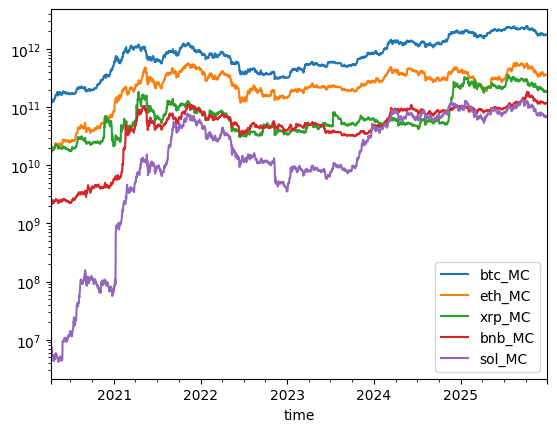

In [29]:
full_df[[f"{t}_MC" for t in tickers]].plot(logy=True)

In [30]:
import pandas as pd

# 1. Process the BNB Chain Data
print("Processing BNB Data...")
df_bnb_artemis = pd.read_csv(
    "Metric Comparison - BNB Chain-2.csv",
    sep=";",
    decimal="," # Crucial: handles European decimal formatting
)
# Fix the datetime index
df_bnb_artemis['DateTime'] = pd.to_datetime(df_bnb_artemis['DateTime'])
df_bnb_artemis.set_index('DateTime', inplace=True)
df_bnb_artemis.index = df_bnb_artemis.index.normalize() # Snap to midnight
df_bnb_artemis.index.name = 'date'

# Rename to match your thesis methodology
df_bnb_artemis = df_bnb_artemis.rename(columns={
    "BNB Chain - Daily Active Users": "bnb_AdrActCnt",
    "BNB Chain - Price": "bnb_PriceUSD_artemis"
})
# We only really need the Active Addresses, but keeping price as backup
df_bnb_artemis = df_bnb_artemis[['bnb_AdrActCnt']]


# 2. Process the Solana Data
print("Processing Solana Data...")
df_sol_artemis = pd.read_csv(
    "metric-comparison-solana-3.csv",
    sep=";",
    decimal=","
)
# Fix the datetime index
df_sol_artemis['DateTime'] = pd.to_datetime(df_sol_artemis['DateTime'])
df_sol_artemis.set_index('DateTime', inplace=True)
df_sol_artemis.index = df_sol_artemis.index.normalize()
df_sol_artemis.index.name = 'date'

# Rename to match your thesis methodology
df_sol_artemis = df_sol_artemis.rename(columns={
    "Solana - Transacting Users": "sol_AdrActCnt",
    "Solana - Price": "sol_PriceUSD_artemis",
    "Solana - Market Cap": "sol_MC_artemis"
})
# We only really need the Active Addresses, but keeping others as backup
df_sol_artemis = df_sol_artemis[['sol_AdrActCnt']]


# 3. Combine them together
altcoin_addrs_df = df_bnb_artemis.join(df_sol_artemis, how='outer')


# 4. Merge into your Master DataFrame (full_df)
print("\nMerging into the Master DataFrame...")
# Assuming 'full_df' is your main dataframe from the CoinMetrics script
# If full_df already has 'bnb_AdrActCnt' columns full of NaNs, we use combine_first to fill the holes
if 'full_df' in locals():
    # If the columns already exist in full_df (but are empty), fill them
    if 'bnb_AdrActCnt' in full_df.columns:
        full_df['bnb_AdrActCnt'] = full_df['bnb_AdrActCnt'].combine_first(altcoin_addrs_df['bnb_AdrActCnt'])
    else:
        full_df = full_df.join(altcoin_addrs_df[['bnb_AdrActCnt']], how='left')

    if 'sol_AdrActCnt' in full_df.columns:
        full_df['sol_AdrActCnt'] = full_df['sol_AdrActCnt'].combine_first(altcoin_addrs_df['sol_AdrActCnt'])
    else:
        full_df = full_df.join(altcoin_addrs_df[['sol_AdrActCnt']], how='left')

    print("Merge Complete! Here is the updated full_df shape:", full_df.shape)
else:
    # If testing this script in isolation:
    full_df = altcoin_addrs_df
    print("Master DataFrame created from Artemis data.")

# Show the results for your 2020-2025 window
thesis_preview = full_df.loc['2020-01-01':'2025-12-31']
print("\nPreview of Active Addresses (2020-2025):")
print(thesis_preview[['bnb_AdrActCnt', 'sol_AdrActCnt']].tail())

Processing BNB Data...
Processing Solana Data...

Merging into the Master DataFrame...
Merge Complete! Here is the updated full_df shape: (2091, 69)

Preview of Active Addresses (2020-2025):
            bnb_AdrActCnt  sol_AdrActCnt
time                                    
2025-12-27      2477298.0      2551914.0
2025-12-28      2428059.0      2706548.0
2025-12-29      2670817.0      3073826.0
2025-12-30      2645238.0      2864890.0
2025-12-31      2677217.0      2730882.0


In [31]:
full_df['bnb_PriceUSD']

time
2020-04-11     13.815938
2020-04-12     14.387897
2020-04-13     15.030767
2020-04-14     15.624805
2020-04-15     14.583946
                 ...    
2025-12-27    843.388466
2025-12-28    858.038102
2025-12-29    851.485048
2025-12-30    860.798478
2025-12-31    863.406483
Freq: D, Name: bnb_PriceUSD, Length: 2091, dtype: float64

In [32]:
import pandas as pd

def check_thesis_data_readiness(df, start_date='2020-01-01', end_date='2025-12-31'):
    """
    Audits the Master DataFrame to ensure all FINAL mathematical variables for the
    Forward-CoVaR thesis model are present and populated.
    """
    print(f"--- FINAL THESIS DATA AUDIT ({start_date} to {end_date}) ---")

    # Slice the dataframe to your exact thesis window
    try:
        df_window = df.loc[start_date:end_date]
        if df_window.empty:
            print("❌ CRITICAL: The dataframe has no data in the specified date range!")
            return
        print(f"Total trading days in window: {len(df_window)}\n")
    except KeyError:
        print("❌ CRITICAL: The dataframe index is not formatted correctly as dates.")
        return

    # 1. Define the exact theoretical requirements
    tickers = ['btc', 'eth', 'xrp', 'bnb', 'sol']

    requirements = {
        # NOW AUDITING THE FINAL 5-VARIABLE MARKET VECTOR
        'Market State Vector (M_t)': ['M_vol', 'M_trend', 'M_fund', 'M_fiat', 'M_volu'],

        'Market Data (All)': ['_PriceUSD', '_MC'],
        'Leverage Intensity (All)': ['_OI'],
        'Network Activity (All)': ['_AdrActCnt'],
        'DeFi Liquidity (ETH, BNB, SOL)': ['eth_TVL', 'bnb_TVL', 'sol_TVL'],
        'PoW Security (BTC, ETH)': ['btc_HashRate', 'eth_HashRate'],
        'Valuation (BTC, ETH, XRP)': ['btc_CapMVRVCur', 'eth_CapMVRVCur', 'xrp_CapMVRVCur']
    }

    missing_cols = []
    empty_cols = []

    # 2. Build the list of exact expected column names
    expected_columns = requirements['Market State Vector (M_t)'].copy()
    expected_columns += requirements['DeFi Liquidity (ETH, BNB, SOL)']
    expected_columns += requirements['PoW Security (BTC, ETH)']
    expected_columns += requirements['Valuation (BTC, ETH, XRP)']

    for t in tickers:
        for suffix in requirements['Market Data (All)'] + requirements['Leverage Intensity (All)'] + requirements['Network Activity (All)']:
            expected_columns.append(f"{t}{suffix}")

    # 3. Perform the Audit
    print(f"{'Variable':<25} | {'Status':<15} | {'Missing Rows':<15}")
    print("-" * 60)

    for col in expected_columns:
        if col not in df_window.columns:
            print(f"❌ {col:<23} | Not Found")
            missing_cols.append(col)
        else:
            missing_count = df_window[col].isna().sum()
            missing_pct = (missing_count / len(df_window)) * 100

            if missing_pct == 100:
                print(f"⚠️ {col:<23} | ALL EMPTY       | {missing_count} (100%)")
                empty_cols.append(col)
            elif missing_pct > 30:
                print(f"⚠️ {col:<23} | High NaNs       | {missing_count} ({missing_pct:.1f}%)")
            else:
                print(f"✅ {col:<23} | OK              | {missing_count} ({missing_pct:.1f}%)")

    # 4. Final Verdict
    print("\n--- AUDIT SUMMARY ---")
    if not missing_cols and not empty_cols:
        print("🎉 PERFECT! Your dataset has all final variables required for the regressions!")
    else:
        if missing_cols:
            print(f"\nMissing completely:\n{', '.join(missing_cols)}")
            print("-> Fix: Check your variable generation blocks.")
        if empty_cols:
            print(f"\nExists but empty:\n{', '.join(empty_cols)}")

# ==========================================
# Run the check:
# check_thesis_data_readiness(full_df)
# ==========================================

In [33]:
check_thesis_data_readiness(full_df)

--- FINAL THESIS DATA AUDIT (2020-01-01 to 2025-12-31) ---
Total trading days in window: 2091

Variable                  | Status          | Missing Rows   
------------------------------------------------------------
✅ M_vol                   | OK              | 0 (0.0%)
✅ M_trend                 | OK              | 0 (0.0%)
❌ M_fund                  | Not Found
✅ M_fiat                  | OK              | 0 (0.0%)
✅ M_volu                  | OK              | 0 (0.0%)
✅ eth_TVL                 | OK              | 0 (0.0%)
✅ bnb_TVL                 | OK              | 203 (9.7%)
✅ sol_TVL                 | OK              | 341 (16.3%)
✅ btc_HashRate            | OK              | 0 (0.0%)
⚠️ eth_HashRate            | High NaNs       | 1204 (57.6%)
✅ btc_CapMVRVCur          | OK              | 0 (0.0%)
✅ eth_CapMVRVCur          | OK              | 0 (0.0%)
✅ xrp_CapMVRVCur          | OK              | 0 (0.0%)
✅ btc_PriceUSD            | OK              | 0 (0.0%)
✅ btc_MC           

In [34]:
import pandas as pd

print("\n--- INTEGRATING REAL API DATA & CALCULATING LEVERAGE INTENSITY ---")

try:
    # 1. Load the real CSV files
    oi_raw = pd.read_csv('thesis_oi_numerator.csv')
    fund_raw = pd.read_csv('thesis_all_oi_weighted_funding.csv')

    # Ensure time columns are datetime objects for a perfect index match
    oi_raw['time'] = pd.to_datetime(oi_raw['time'])
    fund_raw['time'] = pd.to_datetime(fund_raw['time'])

    # ==========================================
    # 2. Process M_fund (Systemic Stress)
    # ==========================================
    # Filter for BTC as the macro proxy
    btc_fund = fund_raw[fund_raw['coin'].str.upper() == 'BTC'][['time', 'M_fund']].copy()
    btc_fund.set_index('time', inplace=True)

    # Merge M_fund into full_df (using left join to preserve your existing dates)
    full_df = full_df.join(btc_fund, how='left')

    # ==========================================
    # 3. Process Raw Open Interest (_OI)
    # ==========================================
    # Lowercase the coin names to match your full_df format ('btc', 'eth', etc.)
    oi_raw['coin'] = oi_raw['coin'].str.lower()

    # Pivot the data from "long" format to "wide" format
    oi_pivoted = oi_raw.pivot(index='time', columns='coin', values='OI_USD')

    # Rename columns to match the audit's expected format ('btc_OI', 'eth_OI')
    oi_pivoted.columns = [f"{col}_OI" for col in oi_pivoted.columns]

    # Merge the pivoted OI columns into full_df
    full_df = full_df.join(oi_pivoted, how='left')

    # ==========================================
    # 4. Calculate Leverage Intensity (_Lev = OI / MC)
    # ==========================================
    tickers = ['btc', 'eth', 'xrp', 'bnb', 'sol']
    for t in tickers:
        oi_col = f'{t}_OI'
        mc_col = f'{t}_MC'
        lev_col = f'{t}_Lev'

        # Check if both columns exist in the df before doing the math
        if oi_col in full_df.columns and mc_col in full_df.columns:
            # THE CORE THESIS MATH: Open Interest / Market Cap
            full_df[lev_col] = full_df[oi_col] / full_df[mc_col]

    print("SUCCESS: Real M_fund, Raw _OI, and Leverage Intensity (_Lev) added to full_df!")

except FileNotFoundError as e:
    print(f"[Fatal Error] Could not find the required CSV file: {e}")
except Exception as e:
    print(f"[Error] Something went wrong during integration: {e}")

# ==========================================
# FINAL THESIS DATA AUDIT
# ==========================================
print("\n--- RUNNING FINAL AUDIT WITH REAL DATA ---")
check_thesis_data_readiness(full_df)


--- INTEGRATING REAL API DATA & CALCULATING LEVERAGE INTENSITY ---
SUCCESS: Real M_fund, Raw _OI, and Leverage Intensity (_Lev) added to full_df!

--- RUNNING FINAL AUDIT WITH REAL DATA ---
--- FINAL THESIS DATA AUDIT (2020-01-01 to 2025-12-31) ---
Total trading days in window: 2091

Variable                  | Status          | Missing Rows   
------------------------------------------------------------
✅ M_vol                   | OK              | 0 (0.0%)
✅ M_trend                 | OK              | 0 (0.0%)
✅ M_fund                  | OK              | 0 (0.0%)
✅ M_fiat                  | OK              | 0 (0.0%)
✅ M_volu                  | OK              | 0 (0.0%)
✅ eth_TVL                 | OK              | 0 (0.0%)
✅ bnb_TVL                 | OK              | 203 (9.7%)
✅ sol_TVL                 | OK              | 341 (16.3%)
✅ btc_HashRate            | OK              | 0 (0.0%)
⚠️ eth_HashRate            | High NaNs       | 1204 (57.6%)
✅ btc_CapMVRVCur          | OK 

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

# Suppress convergence warnings for rolling windows
warnings.filterwarnings('ignore')

print("\n========================================================")
print("PHASE 2: ECONOMETRIC EXECUTION (FORWARD-COVAR ROADMAP)")
print("========================================================\n")

tickers = ['btc', 'eth', 'xrp', 'sol', 'bnb']
macro_vars = ['M_vol', 'M_trend', 'M_fund', 'M_fiat', 'M_volu']

# ==========================================
# 1. DATA REFINEMENT & STATIONARITY
# ==========================================
print("Step 1: Calculating Stationarity Transformations & Log-Growths...")

# Reuse returns and system returns already built in cell 26.
# Cell 26 builds {t}_ret (lowercase) and sys_ret_excl_{t} (cap-weighted).
# We alias to {t}_Ret so downstream cells stay consistent.
for t in tickers:
    full_df[f'{t}_Ret'] = full_df[f'{t}_ret']

# Generate Stationary Coin Characteristics (X_{t-1})
for t in tickers:
    # Leverage (Stationary Ratio)
    if f'{t}_OI' in full_df.columns and f'{t}_MC' in full_df.columns:
        full_df[f'{t}_Lev'] = full_df[f'{t}_OI'] / full_df[f'{t}_MC']

    # Network Vitality (Log-growth)
    if f'{t}_AdrActCnt' in full_df.columns:
        full_df[f'{t}_NetAct'] = np.log(full_df[f'{t}_AdrActCnt']).replace([np.inf, -np.inf], np.nan).diff()

    # DeFi Liquidity Risk (Log-growth of TVL - applies to ETH, BNB, SOL)
    if f'{t}_TVL' in full_df.columns:
        full_df[f'{t}_Liq'] = np.log(full_df[f'{t}_TVL']).replace([np.inf, -np.inf], np.nan).diff()

    # Valuation: MVRV for Ledgers, MC/TVL for DeFi
    if f'{t}_CapMVRVCur' in full_df.columns:
        full_df[f'{t}_Val'] = full_df[f'{t}_CapMVRVCur'] - 1
    elif f'{t}_MC' in full_df.columns and f'{t}_TVL' in full_df.columns:
        full_df[f'{t}_Val'] = full_df[f'{t}_MC'] / full_df[f'{t}_TVL']

# Clean infinites and drop initial NaN rows from differencing
full_df.replace([np.inf, -np.inf], np.nan, inplace=True)
full_df.dropna(subset=macro_vars + [f'sys_ret_excl_{t}' for t in tickers], inplace=True)

# VIF Test Function
def run_vif_test(df_subset, coin_name):
    df_clean = df_subset.dropna()
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df_clean.columns
    vif_data["VIF Score"] = [variance_inflation_factor(df_clean.values, i) for i in range(len(df_clean.columns))]
    print(f"\nVIF Diagnostics for {coin_name.upper()}:")
    print(vif_data.round(2))

# Example VIF execution for ETH
eth_features = ['eth_Lev', 'eth_NetAct', 'eth_Liq', 'eth_Val']
existing_eth_features = [f for f in eth_features if f in full_df.columns]
if existing_eth_features:
    run_vif_test(full_df[existing_eth_features], 'ETH')




PHASE 2: ECONOMETRIC EXECUTION (FORWARD-COVAR ROADMAP)

Step 1: Calculating Stationarity Transformations & Log-Growths...

VIF Diagnostics for ETH:
     Variable  VIF Score
0     eth_Lev       1.26
1  eth_NetAct       1.00
2     eth_Liq       1.03
3     eth_Val       1.29


In [36]:
print("--- FIXING VALUATION LOGIC & RE-RUNNING VIF ---")

# 1. Force explicitly correct Valuation metrics
for t in tickers:
    if t in ['btc', 'xrp']:
        # Pure Ledgers use MVRV
        if f'{t}_CapMVRVCur' in full_df.columns:
            full_df[f'{t}_Val'] = full_df[f'{t}_CapMVRVCur'] - 1
    elif t in ['eth', 'bnb', 'sol']:
        # Smart Contract Platforms use MC / TVL
        if f'{t}_MC' in full_df.columns and f'{t}_TVL' in full_df.columns:
            full_df[f'{t}_Val'] = full_df[f'{t}_MC'] / full_df[f'{t}_TVL']

# 2. Check the fix
print("\nNew NaN counts for BNB:")
print(full_df[['bnb_Val', 'bnb_Liq']].isna().sum())

# 3. Re-run BNB VIF Diagnostics
print("\n--- BNB VIF DIAGNOSTICS ---")
bnb_features = ['bnb_Lev', 'bnb_NetAct', 'bnb_Val', 'bnb_Liq']
existing_bnb_features = [f for f in bnb_features if f in full_df.columns]

# Drop the first 202 days where TVL didn't exist yet, so the math can run
df_clean = full_df[existing_bnb_features].dropna()

if len(df_clean) > 0:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import pandas as pd

    vif_data = pd.DataFrame()
    vif_data["Variable"] = df_clean.columns
    vif_data["VIF Score"] = [variance_inflation_factor(df_clean.values, i) for i in range(len(df_clean.columns))]
    print(f"Calculated on {len(df_clean)} valid rows:")
    print(vif_data.round(2))
else:
    print("Still completely empty!")

--- FIXING VALUATION LOGIC & RE-RUNNING VIF ---

New NaN counts for BNB:
bnb_Val    202
bnb_Liq    203
dtype: int64

--- BNB VIF DIAGNOSTICS ---
Calculated on 1887 valid rows:
     Variable  VIF Score
0     bnb_Lev       1.66
1  bnb_NetAct       1.00
2     bnb_Val       1.68
3     bnb_Liq       1.03


In [37]:
print("\n========================================================")
print("PHASE 3: FULL DIAGNOSTICS & RESULT EXTRACTION")
print("========================================================\n")

# ==========================================
# 1. RUN VIF DIAGNOSTICS FOR ALL COINS
# ==========================================
print("--- FULL PANEL VIF DIAGNOSTICS ---")
for t in tickers:
    # Base characteristics for all coins
    # ── build feature list for VIF Diagnostics ────────────────────────────────
    features = [
        f'{t}_Lev',
        f'{t}_NetAct',
        f'{t}_Val'
    ]

    # Conditionally append DeFi Liquidity Risk (for ETH, SOL, BNB)
    if f'{t}_Liq' in full_df.columns:
        features.append(f'{t}_Liq')

    # Conditionally calculate and append Network Security (for BTC, ETH)
    if t == 'eth' and 'eth_fac_security' in full_df.columns:
        features.append('eth_fac_security')

    elif t == 'btc' and 'btc_HashRate' in full_df.columns:
        # Calculate BTC's log-growth of Hashrate on the fly if it doesn't exist yet
        if 'btc_fac_security' not in full_df.columns:
            full_df['btc_fac_security'] = np.log(full_df['btc_HashRate']).diff()

        # Safely append it to the VIF features
        features.append('btc_fac_security')

    # Check which features actually exist in the dataframe
    existing_features = [f for f in features if f in full_df.columns]

    if existing_features:
        # We must drop NaNs to run VIF
        df_clean = full_df[existing_features].dropna()
        if len(df_clean) > 0:
            vif_data = pd.DataFrame()
            vif_data["Variable"] = df_clean.columns
            vif_data["VIF Score"] = [variance_inflation_factor(df_clean.values, i) for i in range(len(df_clean.columns))]
            print(f"\nVIF Diagnostics for {t.upper()}:")
            print(vif_data.round(2))
        else:
            print(f"\nCould not run VIF for {t.upper()}: No valid data rows after dropping NaNs.")


PHASE 3: FULL DIAGNOSTICS & RESULT EXTRACTION

--- FULL PANEL VIF DIAGNOSTICS ---

VIF Diagnostics for BTC:
           Variable  VIF Score
0           btc_Lev       2.60
1        btc_NetAct       1.14
2           btc_Val       2.60
3  btc_fac_security       1.15

VIF Diagnostics for ETH:
           Variable  VIF Score
0           eth_Lev       1.66
1        eth_NetAct       1.00
2           eth_Val       1.68
3           eth_Liq       1.02
4  eth_fac_security       1.01

VIF Diagnostics for XRP:
     Variable  VIF Score
0     xrp_Lev       1.37
1  xrp_NetAct       1.00
2     xrp_Val       1.37

VIF Diagnostics for SOL:
     Variable  VIF Score
0     sol_Lev       1.86
1  sol_NetAct       1.00
2     sol_Val       1.87
3     sol_Liq       1.01

VIF Diagnostics for BNB:
     Variable  VIF Score
0     bnb_Lev       1.66
1  bnb_NetAct       1.00
2     bnb_Val       1.68
3     bnb_Liq       1.03


In [38]:
print("--- BNB MISSING DATA DIAGNOSTIC ---")
bnb_cols = [
    'bnb_MC', 'bnb_OI', 'bnb_TVL', 'bnb_AdrActCnt',
    'bnb_Lev', 'bnb_NetAct', 'bnb_Val', 'bnb_Liq'
]

# Filter to only the columns that actually exist in your dataframe
existing_bnb_cols = [c for c in bnb_cols if c in full_df.columns]

print(f"Total rows in dataset: {len(full_df)}\n")
print(full_df[existing_bnb_cols].isna().sum())

--- BNB MISSING DATA DIAGNOSTIC ---
Total rows in dataset: 2090

bnb_MC             0
bnb_OI             0
bnb_TVL          202
bnb_AdrActCnt    139
bnb_Lev            0
bnb_NetAct       140
bnb_Val          202
bnb_Liq          203
dtype: int64


In [42]:
# =============================================================================
# FORWARD-CoVaR QUANTILE REGRESSION ENGINE
# MsC Thesis: Measuring Systemic Risk in the Cryptocurrency Market
# =============================================================================
# Implements:
#   1. Unconditional CoVaR  (Adrian & Brunnermeier 2016, eq. 1-3)
#   2. Conditional CoVaR    (A&B 2016, eq. 4-6)
#   3. Forward-CoVaR        (A&B 2016, eq. 7)
#   4. Backtesting          (Kupiec POF + Christoffersen Independence)
#   5. Pinball loss         (out-of-sample forecast evaluation)
#   6. Results tables + visualisations
#
# USAGE:  append this file to your existing notebook / run after full_df is built
# All column names match those produced by thesismsc.py
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore")

# ── colour palette (consistent across all plots) ────────────────────────────
COLORS = {
    "btc": "#F7931A", "eth": "#627EEA",
    "xrp": "#346AA9", "bnb": "#F3BA2F", "sol": "#9945FF"
}

TICKERS  = ["btc", "eth", "xrp", "bnb", "sol"]
QUANTILE = 0.05          # tail quantile (5 % left tail)
HORIZON  = 1             # Forward-CoVaR forecast horizon (days)


# =============================================================================
# SECTION 0 – FEATURE CONSTRUCTION
# =============================================================================
# Builds the derived variables that may not yet exist in full_df.
# Safe to re-run; existing columns are overwritten.

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Constructs all coin-characteristic variables required for the regressions.
    Expects the column naming conventions produced by thesismsc.py.
    """
    df = df.copy()

    for t in TICKERS:
        # ── Log returns (idempotent) ──────────────────────────────────────
        price_col = f"{t}_PriceUSD"
        if price_col in df.columns:
            df[f"{t}_ret"] = np.log(df[price_col]).diff()

        # ── Leverage intensity: OI / MC ───────────────────────────────────
        oi_col = f"{t}_OI"
        mc_col = f"{t}_MC"
        if oi_col in df.columns and mc_col in df.columns:
            df[f"{t}_fac_lev"] = df[oi_col] / df[mc_col].replace(0, np.nan)

        # ── Network vitality: Δ ln(active addresses) ──────────────────────
        aa_col = f"{t}_AdrActCnt"
        if aa_col in df.columns:
            df[f"{t}_fac_netact"] = np.log(df[aa_col].replace(0, np.nan)).diff()

        # ── DeFi liquidity: Δ ln(TVL)  (ETH, BNB, SOL only) ─────────────
        tvl_col = f"{t}_TVL"
        if tvl_col in df.columns:
            df[f"{t}_fac_liq"] = np.log(df[tvl_col].replace(0, np.nan)).diff()

        # ── Valuation (ledger: BTC, XRP; DeFi: SOL, BNB; ETH both) ──────
        mvrv_col = f"{t}_CapMVRVCur"
        if mvrv_col in df.columns and f"{t}_fac_val" not in df.columns:
            df[f"{t}_fac_val"] = df[mvrv_col] - 1

        # MC/TVL fallback for DeFi assets
        if f"{t}_fac_val" not in df.columns:
            if mc_col in df.columns and tvl_col in df.columns:
                df[f"{t}_fac_val"] = (
                    df[mc_col] / df[tvl_col].replace(0, np.nan)
                )

    # ── PoW security: Δ ln(hashrate) × PoW dummy ────────────────────────
    if "btc_HashRate" in df.columns:
        df["btc_fac_security"] = np.log(
            df["btc_HashRate"].replace(0, np.nan)
        ).diff()

    # ETH PoW dummy already handled in thesismsc.py; replicate if absent
    if "eth_fac_security" not in df.columns and "eth_HashRate" in df.columns:
        eth_pow = (df.index < "2022-09-15").astype(float)
        df["eth_fac_security"] = (
            np.log(df["eth_HashRate"].replace(0, np.nan)).diff() * eth_pow
        )

    return df


def get_coin_chars(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """
    Returns the coin-characteristic matrix X_i for a given ticker.
    Matches the exact column names constructed in your main thesis dataframe.
    """
    candidate_cols = {
        "lev":      f"{ticker}_Lev",
        "netact":   f"{ticker}_NetAct",
        "val":      f"{ticker}_Val",
        "liq":      f"{ticker}_Liq",
        "security": f"{ticker}_fac_security",
    }
    # Only keep columns that actually exist in the dataframe and aren't entirely NaNs
    present = {
        k: v for k, v in candidate_cols.items()
        if v in df.columns and not df[v].isna().all()
    }
    return df[list(present.values())].copy()


def get_market_state(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns the market-state matrix M_{t-1}.
    Drops any column that is fully missing.
    """
    m_cols = ["M_vol", "M_trend", "M_fund", "M_fiat", "M_volu"]
    present = [c for c in m_cols if c in df.columns and not df[c].isna().all()]
    if not present:
        raise ValueError(
            "No market state variables found. "
            "Check that M_vol / M_trend / M_fiat / M_volu are built "
            "and that M_fund (funding rate) is merged into full_df."
        )
    return df[present].copy()


# =============================================================================
# SECTION 1 – UNCONDITIONAL CoVaR
# =============================================================================

def estimate_unconditional_covar(
    df: pd.DataFrame,
    ticker: str,
    q: float = QUANTILE
) -> pd.DataFrame:
    """
    Estimates static (unconditional) VaR and CoVaR via quantile regression.

    Step 1  –  VaR_i  :  r_i  = α_q  +  ε_q          (eq. 1)
    Step 2  –  CoVaR  :  r_sys = α_q^{sys|i}
                               + β_q^{sys|i} * r_i  +  ε_q    (eq. 2)
    Step 3  –  ΔCoVaR :  CoVaR(distress) − CoVaR(median)      (eq. 3)

    Returns a DataFrame indexed like df with columns:
        VaR_i, CoVaR_distress, CoVaR_median, DeltaCoVaR
    """
    ret_i   = df[f"{ticker}_ret"].dropna()
    ret_sys = df[f"sys_ret_excl_{ticker}"].reindex(ret_i.index).dropna()
    idx     = ret_i.index.intersection(ret_sys.index)

    ri  = ret_i.loc[idx].values
    rs  = ret_sys.loc[idx].values

    # ── Step 1: unconditional VaR at quantile q ──────────────────────────
    mod_var = QuantReg(ri, np.ones(len(ri)))
    res_var = mod_var.fit(q=q, vcov="iid")
    VaR_q   = float(res_var.params[0])          # scalar (constant model)

    res_med = mod_var.fit(q=0.5, vcov="iid")
    VaR_50  = float(res_med.params[0])

    # ── Step 2: CoVaR at quantile q ──────────────────────────────────────
    X       = add_constant(ri, has_constant="add")
    mod_cov = QuantReg(rs, X)
    res_cov = mod_cov.fit(q=q, vcov="iid")
    a_q, b_q = res_cov.params                   # intercept, slope

    # ── Step 3: ΔCoVaR ───────────────────────────────────────────────────
    CoVaR_distress = a_q + b_q * VaR_q
    CoVaR_median   = a_q + b_q * VaR_50
    DeltaCoVaR     = CoVaR_distress - CoVaR_median

    out = pd.DataFrame(
        {
            "VaR_i":           VaR_q,
            "CoVaR_distress":  CoVaR_distress,
            "CoVaR_median":    CoVaR_median,
            "DeltaCoVaR":      DeltaCoVaR,
        },
        index=idx
    )
    return out


# =============================================================================
# SECTION 2 – CONDITIONAL (TIME-VARYING) CoVaR
# =============================================================================

def estimate_conditional_covar(
    df: pd.DataFrame,
    ticker: str,
    q: float = QUANTILE
) -> pd.DataFrame:
    """
    Estimates time-varying VaR and CoVaR conditioned on market state M_{t-1}.

    Step 1  –  r_i_t  = α_q + β_q' M_{t-1}  +  ε_q             (eq. 4)
    Step 2  –  r_sys  = α_q^{sys|i} + β_q^{sys|i}' M_{t-1}
                      + γ_q^{sys|i} r_i  +  ε_q                 (eq. 5)
    Step 3  –  ΔCoVaR_t  =  CoVaR(r_i=VaR_q,t) − CoVaR(r_i=VaR_50,t) (eq. 6)

    Returns a DataFrame with columns:
        VaR_q_t, VaR_50_t, DeltaCoVaR_t
    plus coefficient DataFrames for both regressions (stored as attributes).
    """
    M   = get_market_state(df).shift(1)          # lag by 1 day
    ri  = df[f"{ticker}_ret"]
    rs  = df[f"sys_ret_excl_{ticker}"]

    # Align all series on a common clean index
    combined = pd.concat([ri, rs, M], axis=1).dropna()
    ri_  = combined.iloc[:, 0].values
    rs_  = combined.iloc[:, 1].values
    M_   = combined.iloc[:, 2:].values
    idx  = combined.index

    n_m  = M_.shape[1]

    # ── Step 1: VaR_i conditional on M ──────────────────────────────────
    X_var    = np.column_stack([np.ones(len(ri_)), M_])    # [1, M]
    mod_vq   = QuantReg(ri_, X_var)
    res_vq   = mod_vq.fit(q=q,   vcov="iid")
    res_v50  = mod_vq.fit(q=0.5, vcov="iid")

    VaR_q_t  = X_var @ res_vq.params               # fitted quantile path
    VaR_50_t = X_var @ res_v50.params

    # ── Step 2: CoVaR conditional on M and r_i ──────────────────────────
    # Design matrix: [1, M, r_i]
    X_cov    = np.column_stack([np.ones(len(rs_)), M_, ri_])
    mod_cov  = QuantReg(rs_, X_cov)
    res_cov  = mod_cov.fit(q=q, vcov="iid")

    # α, β (M coefficients), γ (coin return coefficient)
    alpha_q  = res_cov.params[0]
    beta_q   = res_cov.params[1:1 + n_m]
    gamma_q  = res_cov.params[-1]

    # ── Step 3: ΔCoVaR_t ────────────────────────────────────────────────
    # CoVaR at distress:  α + β'M + γ * VaR_q_t
    # CoVaR at median:    α + β'M + γ * VaR_50_t
    M_part        = M_ @ beta_q
    CoVaR_dist_t  = alpha_q + M_part + gamma_q * VaR_q_t
    CoVaR_med_t   = alpha_q + M_part + gamma_q * VaR_50_t
    DeltaCoVaR_t  = CoVaR_dist_t - CoVaR_med_t

    result = pd.DataFrame(
        {
            "VaR_q_t":      VaR_q_t,
            "VaR_50_t":     VaR_50_t,
            "CoVaR_dist_t": CoVaR_dist_t,
            "CoVaR_med_t":  CoVaR_med_t,
            "DeltaCoVaR_t": DeltaCoVaR_t,
        },
        index=idx
    )

    # Attach regression summaries as attributes for later inspection
    result.attrs["var_params"]  = pd.Series(res_vq.params,
                                            index=["const"] + list(combined.columns[2:]))
    result.attrs["covar_params"] = pd.Series(
        res_cov.params,
        index=["const"] + list(combined.columns[2:]) + [f"{ticker}_ret"]
    )
    result.attrs["var_pvalues"]   = res_vq.pvalues
    result.attrs["covar_pvalues"] = res_cov.pvalues

    return result


# =============================================================================
# SECTION 3 – FORWARD-CoVaR  (predictive regression, eq. 7)
# =============================================================================
def estimate_rolling_delta_covar(
    df: pd.DataFrame, ticker: str, q: float = QUANTILE, window: int = 250
) -> pd.Series:
    """
    Estimates time-varying ΔCoVaR using a rolling window.
    Safely rewritten using Pandas to perfectly match statsmodels alignments.
    """
    ri  = df[f"{ticker}_ret"]
    rs  = df[f"sys_ret_excl_{ticker}"]
    M   = get_market_state(df)

    # Drop NaNs to ensure a contiguous rolling window without gaps
    combined = pd.concat([ri, rs, M], axis=1).dropna()

    delta_vals = []
    delta_idx  = []

    macro_cols = list(M.columns)
    asset_name = ri.name

    for i in range(window, len(combined)):
        win = combined.iloc[i - window : i]

        y_asset = win[asset_name]
        y_sys   = win.iloc[:, 1]
        X_macro = add_constant(win[macro_cols])

        # Construct prediction row for time t
        pred_X = combined.iloc[i:i+1][macro_cols].copy()
        pred_X.insert(0, 'const', 1.0)

        try:
            # 1. Asset VaR Regressions
            model_vq  = QuantReg(y_asset, X_macro).fit(q=q, p_tol=1e-4, max_iter=2000)
            model_v50 = QuantReg(y_asset, X_macro).fit(q=0.50, p_tol=1e-4, max_iter=2000)

            var_q  = model_vq.predict(pred_X).iloc[0]
            var_50 = model_v50.predict(pred_X).iloc[0]

            # 2. System CoVaR Regression
            X_sys = pd.concat([y_asset, win[macro_cols]], axis=1)
            X_sys = add_constant(X_sys)

            model_covar = QuantReg(y_sys, X_sys).fit(q=q, p_tol=1e-4, max_iter=2000)

            # Extract gamma (the coefficient for the asset return)
            gamma_q = model_covar.params[asset_name]

            # Compute Delta CoVaR
            delta_vals.append(gamma_q * (var_q - var_50))
            delta_idx.append(combined.index[i])

        except Exception as e:
            # If it fails, append NaN so it doesn't break the time-series sync
            delta_vals.append(np.nan)
            delta_idx.append(combined.index[i])

    return pd.Series(delta_vals, index=delta_idx, name=f"DeltaCoVaR_rolling_{ticker}")


def estimate_forward_covar(
    df: pd.DataFrame, ticker: str, delta_covar_series: pd.Series,
    q: float = QUANTILE, horizon: int = HORIZON, test_size: float = 0.25,
    scale_features: bool = True, use_quantreg: bool = True
) -> dict:

    # 1. Catch silent rolling failures instantly
    if delta_covar_series.isna().all():
        raise ValueError("Rolling regressions failed entirely (returned all NaNs).")

    M  = get_market_state(df).shift(horizon)
    X  = get_coin_chars(df, ticker).shift(horizon)
    y  = delta_covar_series.rename("DeltaCoVaR")

    combined = pd.concat([y, M, X], axis=1).dropna()

    # 2. Catch empty dataframes before triggering the NumPy crash
    if len(combined) < 50:
        raise ValueError(f"Not enough data after aligning/dropping NaNs (found {len(combined)} rows). Check for missing coin characteristics.")

    y_arr  = combined["DeltaCoVaR"].values
    Xm_arr = combined.drop(columns=["DeltaCoVaR"]).values
    feat_names = list(combined.drop(columns=["DeltaCoVaR"]).columns)

    split   = int(len(y_arr) * (1 - test_size))
    X_tr_raw = Xm_arr[:split]
    X_te_raw = Xm_arr[split:]
    
    if scale_features:
        # --- Z-Score Standardization to maintain valid Feature Importance ---
        train_mean = np.mean(X_tr_raw, axis=0)
        train_std = np.std(X_tr_raw, axis=0)
        train_std[train_std == 0] = 1.0 # prevent div-by-zero
        
        X_tr_scaled = (X_tr_raw - train_mean) / train_std
        X_te_scaled = (X_te_raw - train_mean) / train_std
        
        X_tr = add_constant(X_tr_scaled, has_constant="add")
        X_te = add_constant(X_te_scaled, has_constant="add")
    else:
        X_tr = add_constant(X_tr_raw, has_constant="add")
        X_te = add_constant(X_te_raw, has_constant="add")
    y_tr, y_te = y_arr[:split],  y_arr[split:]
    idx_tr     = combined.index[:split]
    idx_te     = combined.index[split:]

    mod  = QuantReg(y_tr, X_tr)
    res  = mod.fit(q=q, p_tol=1e-4, max_iter=2000)

    fitted   = res.predict(X_tr)
    forecast = res.predict(X_te)

    resid_full = y_tr - fitted
    base_mod   = QuantReg(y_tr, np.ones(len(y_tr)))
    base_res   = base_mod.fit(q=q, p_tol=1e-4, max_iter=2000)
    resid_base = y_tr - base_res.predict()

    def _check_loss(resid, q):
        return np.mean(resid * (q - (resid < 0).astype(float)))

    r2_is = 1 - _check_loss(resid_full, q) / _check_loss(resid_base, q)

    pinball_is  = _check_loss(y_tr - fitted,    q)
    pinball_oos = _check_loss(y_te - forecast,  q)

    param_names = ["const"] + feat_names
    params_df = pd.DataFrame(
        {"coef": res.params, "pvalue": res.pvalues, "tstat": res.tvalues},
        index=param_names
    )

    return {
        "fitted":        pd.Series(fitted,   index=idx_tr, name="FwdCoVaR_fitted"),
        "forecast":      pd.Series(forecast, index=idx_te, name="FwdCoVaR_forecast"),
        "actual":        pd.Series(y_te,     index=idx_te, name="DeltaCoVaR_actual"),
        "params":        params_df,
        "pinball_is":    pinball_is,
        "pinball_oos":   pinball_oos,
        "r2_is":         r2_is,
        "feature_names": feat_names,
    }
    def _check_loss(resid, q):
        return np.mean(resid * (q - (resid < 0).astype(float)))

    r2_is = 1 - _check_loss(resid_full, q) / _check_loss(resid_base, q)

    # ── Pinball (quantile) loss ──────────────────────────────────────────
    pinball_is  = _check_loss(y_tr - fitted,    q)
    pinball_oos = _check_loss(y_te - forecast,  q)

    # ── Coefficient table ────────────────────────────────────────────────
    param_names = ["const"] + feat_names
    params_df = pd.DataFrame(
        {
            "coef":   res.params,
            "pvalue": res.pvalues,
            "tstat":  res.tvalues,
        },
        index=param_names
    )

    return {
        "fitted":        pd.Series(fitted,   index=idx_tr, name="FwdCoVaR_fitted"),
        "forecast":      pd.Series(forecast, index=idx_te, name="FwdCoVaR_forecast"),
        "actual":        pd.Series(y_te,     index=idx_te, name="DeltaCoVaR_actual"),
        "params":        params_df,
        "pinball_is":    pinball_is,
        "pinball_oos":   pinball_oos,
        "r2_is":         r2_is,
        "feature_names": feat_names,
    }



def estimate_forward_covar_expanding(
    df: pd.DataFrame, ticker: str, delta_covar_series: pd.Series,
    q: float = QUANTILE, horizon: int = HORIZON, min_train_size: int = 500,
    scale_features: bool = True, use_quantreg: bool = True
) -> dict:
    """
    Estimates Forward-CoVaR using an Expanding Window approach for out-of-sample prediction.
    As per the thesis methodology, variables are handled for scale and stationarity via 
    log-differences prior to this step, so no additional Z-score standardization is 
    applied to preserve economic interpretability of the coefficients.
    """
    import numpy as np
    from statsmodels.regression.quantile_regression import QuantReg
    from statsmodels.tools import add_constant

    if delta_covar_series.isna().all():
        raise ValueError("Rolling regressions failed entirely (returned all NaNs).")

    # Shift predictors by the forecast horizon
    M  = get_market_state(df).shift(horizon)
    X  = get_coin_chars(df, ticker).shift(horizon)
    y  = delta_covar_series.rename("DeltaCoVaR")

    combined = pd.concat([y, M, X], axis=1).dropna()

    if len(combined) <= min_train_size:
        raise ValueError(f"Not enough data for expanding window with min_train_size={min_train_size} (found {len(combined)} rows).")

    y_arr  = combined["DeltaCoVaR"].values
    Xm_arr = combined.drop(columns=["DeltaCoVaR"]).values
    feat_names = list(combined.drop(columns=["DeltaCoVaR"]).columns)
    
    forecasts = []
    forecast_idx = []
    
    # ── Expanding Window OOS Forecasting ──────────────────────────────────
    # Re-trains the model every day to predict day T+1
    for i in range(min_train_size, len(combined)):
        # Train on [0 : i], predict on [i]
        X_train  = Xm_arr[:i]
        y_train  = y_arr[:i]
        X_test   = Xm_arr[i:i+1] # Single day test slice
        
        if scale_features:
            # --- Dynamic Z-Score Standardization ---
            tr_mean = np.mean(X_train, axis=0)
            tr_std  = np.std(X_train, axis=0)
            tr_std[tr_std == 0] = 1.0
            
            X_train_sc = (X_train - tr_mean) / tr_std
            X_test_sc  = (X_test - tr_mean) / tr_std
            
            X_tr = add_constant(X_train_sc, has_constant="add")
            X_te = add_constant(X_test_sc, has_constant="add")
        else:
            X_tr = add_constant(X_train, has_constant="add")
            X_te = add_constant(X_test, has_constant="add")
        
        # Fit Quantile Regression and Predict
        if use_quantreg:
            mod = QuantReg(y_train, X_tr)
            res = mod.fit(q=q, p_tol=1e-4, max_iter=2000)
        else:
            mod = sm.OLS(y_train, X_tr)
            res = mod.fit()
        
        forecast = res.predict(X_te)[0]
        forecasts.append(forecast)
        forecast_idx.append(combined.index[i])

    # ── Final Reporting Model ──────────────────────────────────────────────
    # Refits on the entire dataset to generate the coefficients for your thesis tables
    if scale_features:
        full_mean = np.mean(Xm_arr, axis=0)
        full_std = np.std(Xm_arr, axis=0)
        full_std[full_std == 0] = 1.0
        Xm_arr_final = (Xm_arr - full_mean) / full_std
    else:
        Xm_arr_final = Xm_arr
    Xreg_full = add_constant(Xm_arr_final, has_constant="add")
    
    if use_quantreg:
        mod_full = QuantReg(y_arr, Xreg_full)
        res_full = mod_full.fit(q=q, p_tol=1e-4, max_iter=2000)
    else:
        mod_full = sm.OLS(y_arr, Xreg_full)
        res_full = mod_full.fit()
        
    fitted_full = res_full.predict(Xreg_full)
    
    # ── Loss Metrics ─────────────────────────────────────────────
    resid_full = y_arr - fitted_full
    y_test_actual = y_arr[min_train_size:]

    if use_quantreg:
        def _check_loss(resid, q_val):
            return np.mean(resid * (q_val - (resid < 0).astype(float)))

        base_mod   = QuantReg(y_arr, np.ones(len(y_arr)))
        base_res   = base_mod.fit(q=q, p_tol=1e-4, max_iter=2000)
        resid_base = y_arr - base_res.predict()

        r2_all = 1 - _check_loss(resid_full, q) / _check_loss(resid_base, q)
        loss_is  = _check_loss(resid_full, q)
        loss_oos = _check_loss(y_test_actual - forecasts, q)
        loss_name = "Pinball"
    else:
        r2_all = res_full.rsquared
        loss_is  = np.mean(resid_full ** 2)
        loss_oos = np.mean((y_test_actual - forecasts) ** 2)
        loss_name = "MSE"

    param_names = ["const"] + feat_names
    params_df = pd.DataFrame(
        {"coef": res_full.params, "pvalue": res_full.pvalues, "tstat": res_full.tvalues},
        index=param_names
    )

    return {
        "fitted":        pd.Series(fitted_full, index=combined.index, name="FwdCoVaR_fitted"),
        "forecast":      pd.Series(forecasts, index=forecast_idx, name="FwdCoVaR_forecast"),
        "actual":        pd.Series(y_test_actual, index=forecast_idx, name="DeltaCoVaR_actual"),
        "params":        params_df,
        "loss_is":       loss_is,
        "loss_oos":      loss_oos,
        "loss_name":     loss_name,
        "r2_is":         r2_all,
        "feature_names": feat_names,
    }

# =============================================================================
# SECTION 4 – BACKTESTING  (Kupiec + Christoffersen)
# =============================================================================

def kupiec_pof_test(returns: np.ndarray, var_forecasts: np.ndarray,
                    q: float = QUANTILE) -> dict:
    """
    Kupiec (1995) Proportion of Failures (POF) test.

    H0: violation frequency = q  (correctly specified VaR)
    Returns LR statistic and p-value.
    """
    violations = (returns < var_forecasts).astype(int)
    T  = len(violations)
    N  = violations.sum()
    p  = N / T                                    # observed failure rate

    if p == 0 or p == 1:
        return {"N": N, "T": T, "p_hat": p, "LR": np.nan, "pvalue": np.nan,
                "reject_H0": None}

    LR = -2 * (
        np.log((1 - q) ** (T - N) * q ** N)
        - np.log((1 - p) ** (T - N) * p ** N)
    )
    pvalue = 1 - stats.chi2.cdf(LR, df=1)
    return {
        "N": N, "T": T, "p_hat": round(p, 4),
        "LR": round(LR, 4), "pvalue": round(pvalue, 4),
        "reject_H0": pvalue < 0.05
    }


def christoffersen_independence_test(returns: np.ndarray,
                                     var_forecasts: np.ndarray,
                                     q: float = QUANTILE) -> dict:
    """
    Christoffersen (1998) independence test.

    Tests whether VaR violations cluster (reject H0 = violations are i.i.d.).
    """
    hits = (returns < var_forecasts).astype(int)
    T    = len(hits)

    # Transition counts
    n00 = np.sum((hits[:-1] == 0) & (hits[1:] == 0))
    n01 = np.sum((hits[:-1] == 0) & (hits[1:] == 1))
    n10 = np.sum((hits[:-1] == 1) & (hits[1:] == 0))
    n11 = np.sum((hits[:-1] == 1) & (hits[1:] == 1))

    # Transition probabilities
    pi_01 = n01 / (n00 + n01 + 1e-12)
    pi_11 = n11 / (n10 + n11 + 1e-12)
    pi    = (n01 + n11) / (n00 + n01 + n10 + n11 + 1e-12)

    # Likelihood ratio
    def _safe_log(x):
        return np.log(x) if x > 0 else 0.0

    logL_uncond = (
        (n00 + n10) * _safe_log(1 - pi)
        + (n01 + n11) * _safe_log(pi)
    )
    logL_cond = (
        n00 * _safe_log(1 - pi_01) + n01 * _safe_log(pi_01)
        + n10 * _safe_log(1 - pi_11) + n11 * _safe_log(pi_11)
    )

    LR_ind = -2 * (logL_uncond - logL_cond)
    pvalue = 1 - stats.chi2.cdf(LR_ind, df=1)

    return {
        "pi_01": round(pi_01, 4), "pi_11": round(pi_11, 4),
        "LR_ind": round(LR_ind, 4), "pvalue": round(pvalue, 4),
        "reject_H0": pvalue < 0.05
    }


def run_backtests(df: pd.DataFrame, ticker: str,
                  cond_results: pd.DataFrame,
                  q: float = QUANTILE) -> dict:
    """
    Runs both Kupiec and Christoffersen tests on the conditional VaR forecasts.
    Uses the last 25 % of the sample as the evaluation window.
    """
    ret_col = f"{ticker}_ret"
    combined = pd.concat(
        [df[ret_col], cond_results["VaR_q_t"]], axis=1
    ).dropna()

    split   = int(len(combined) * 0.75)
    r_test  = combined.iloc[split:, 0].values
    var_test = combined.iloc[split:, 1].values

    kupiec  = kupiec_pof_test(r_test, var_test, q)
    christ  = christoffersen_independence_test(r_test, var_test, q)

    return {"kupiec": kupiec, "christoffersen": christ,
            "n_test": len(r_test)}


# =============================================================================
# SECTION 5 – FULL PIPELINE
# =============================================================================

def run_full_pipeline(df: pd.DataFrame,
                      q: float = QUANTILE,
                      horizon: int = HORIZON,
                      scale_features: bool = True,
                      use_expanding: bool = False,
                      use_quantreg: bool = True,
                      verbose: bool = True) -> dict:
    """
    Runs the complete Forward-CoVaR pipeline for all tickers and returns
    a results dictionary with all intermediate outputs.
    """
    df = build_features(df)

    results = {}

    for ticker in TICKERS:
        if verbose:
            print(f"\n{'='*60}")
            print(f"  Processing: {ticker.upper()}")
            print(f"{'='*60}")

        res = {}

        # ── 1. Unconditional CoVaR ────────────────────────────────────────
        try:
            uncond = estimate_unconditional_covar(df, ticker, q)
            res["unconditional"] = uncond
            if verbose:
                print(f"  [1] Unconditional ΔCoVaR : {uncond['DeltaCoVaR'].mean():.4f}")
        except Exception as e:
            print(f"  [ERROR] Unconditional CoVaR for {ticker}: {e}")

        # ── 2. Conditional CoVaR ─────────────────────────────────────────
        try:
            cond = estimate_conditional_covar(df, ticker, q)
            res["conditional"] = cond
            if verbose:
                print(f"  [2] Conditional ΔCoVaR (mean): "
                      f"{cond['DeltaCoVaR_t'].mean():.4f}")
                print(f"      γ (coin return coeff):      "
                      f"{cond.attrs['covar_params'].iloc[-1]:.4f}")
        except Exception as e:
            print(f"  [ERROR] Conditional CoVaR for {ticker}: {e}")

        # ── 3. Forward-CoVaR ─────────────────────────────────────────────
        try:
            if "conditional" in res:
                rolling_dcovar = estimate_rolling_delta_covar(df, ticker, q=q)
                res["rolling_dcovar"] = rolling_dcovar

                if use_expanding:
                    fwd = estimate_forward_covar_expanding(df, ticker, rolling_dcovar, q=q, horizon=horizon, scale_features=scale_features, use_quantreg=use_quantreg)
                else:
                    fwd = estimate_forward_covar(df, ticker, rolling_dcovar, q=q, horizon=horizon, scale_features=scale_features, use_quantreg=use_quantreg)

                res["forward"] = fwd
                if verbose:
                    print(f"  [3] Forward-CoVaR  |  Pseudo-R² = {fwd['r2_is']:.4f}"
                          f"  |  {fwd['loss_name']} OOS = {fwd['loss_oos']:.6f}")
        except Exception as e:
            print(f"  [ERROR] Forward-CoVaR for {ticker}: {e}")

        # ── 4. Backtests ──────────────────────────────────────────────────
        try:
            if "conditional" in res:
                bt = run_backtests(df, ticker, res["conditional"], q)
                res["backtests"] = bt
                if verbose:
                    kp = bt["kupiec"]
                    ch = bt["christoffersen"]
                    print(f"  [4] Kupiec  : LR={kp['LR']}, p={kp['pvalue']}, "
                          f"reject={kp['reject_H0']}")
                    print(f"      Christ. : LR={ch['LR_ind']}, p={ch['pvalue']}, "
                          f"reject={ch['reject_H0']}")
        except Exception as e:
            print(f"  [ERROR] Backtests for {ticker}: {e}")

        results[ticker] = res

    return results


# =============================================================================
# SECTION 6 – RESULTS TABLES
# =============================================================================

def make_unconditional_ranking_table(results: dict) -> pd.DataFrame:
    """
    Table 1 in the thesis: static ΔCoVaR ranking across coins.
    """
    rows = []
    for t in TICKERS:
        if "unconditional" not in results.get(t, {}):
            continue
        unc = results[t]["unconditional"]
        rows.append({
            "Coin":       t.upper(),
            "VaR (5%)":   round(unc["VaR_i"].mean(), 4),
            "CoVaR (5%)": round(unc["CoVaR_distress"].mean(), 4),
            "ΔCoVaR":     round(unc["DeltaCoVaR"].mean(), 4),
        })
    df_rank = pd.DataFrame(rows).sort_values("ΔCoVaR")
    df_rank.insert(0, "Rank", range(1, len(df_rank) + 1))
    return df_rank.set_index("Rank")


def make_conditional_ranking_table(results: dict) -> pd.DataFrame:
    """
    Table 2: time-averaged conditional ΔCoVaR ranking.
    """
    rows = []
    for t in TICKERS:
        if "conditional" not in results.get(t, {}):
            continue
        cond = results[t]["conditional"]
        rows.append({
            "Coin":             t.upper(),
            "Mean ΔCoVaR_t":    round(cond["DeltaCoVaR_t"].mean(), 4),
            "Min ΔCoVaR_t":     round(cond["DeltaCoVaR_t"].min(),  4),
            "Max ΔCoVaR_t":     round(cond["DeltaCoVaR_t"].max(),  4),
        })
    df_rank = pd.DataFrame(rows).sort_values("Mean ΔCoVaR_t")
    df_rank.insert(0, "Rank", range(1, len(df_rank) + 1))
    return df_rank.set_index("Rank")


def make_forward_covar_table(results: dict) -> pd.DataFrame:
    """
    Table 3: Forward-CoVaR regression coefficients and fit statistics.
    """
    rows = []
    for t in TICKERS:
        if "forward" not in results.get(t, {}):
            continue
        fwd = results[t]["forward"]
        row = {"Coin": t.upper(),
               "Pseudo-R²": round(fwd["r2_is"], 4),
               f"{fwd['loss_name']} IS": round(fwd["loss_is"], 6),
               f"{fwd['loss_name']} OOS": round(fwd["loss_oos"], 6)}
        for feat, coef, pval in zip(
            fwd["params"].index,
            fwd["params"]["coef"],
            fwd["params"]["pvalue"]
        ):
            row[f"β_{feat}"]  = round(coef,  4)
            row[f"p_{feat}"]  = round(pval,  4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Coin")


def make_backtest_table(results: dict) -> pd.DataFrame:
    """
    Table 4: Backtest summary (Kupiec + Christoffersen).
    """
    rows = []
    for t in TICKERS:
        bt = results.get(t, {}).get("backtests")
        if bt is None:
            continue
        kp = bt["kupiec"]
        ch = bt["christoffersen"]
        rows.append({
            "Coin":        t.upper(),
            "N obs":       bt["n_test"],
            "Violations":  kp["N"],
            "Viol. rate":  kp["p_hat"],
            "Kupiec LR":   kp["LR"],
            "Kupiec p":    kp["pvalue"],
            "Kupiec pass": "✓" if not kp["reject_H0"] else "✗",
            "Christ. LR":  ch["LR_ind"],
            "Christ. p":   ch["pvalue"],
            "Christ. pass":"✓" if not ch["reject_H0"] else "✗",
        })
    return pd.DataFrame(rows).set_index("Coin")


# =============================================================================
# SECTION 7 – VISUALISATIONS
# =============================================================================

def plot_dynamic_covar(results: dict, save_path: str = None):
    """
    Figure 1: Time-varying ΔCoVaR for all coins on a single plot.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    for t in TICKERS:
        cond = results.get(t, {}).get("conditional")
        if cond is None:
            continue
        s = cond["DeltaCoVaR_t"]
        ax.plot(s.index, s.values, label=t.upper(),
                color=COLORS[t], linewidth=1.1, alpha=0.85)

    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title("Time-Varying ΔCoVaR – Systemic Risk Contributions",
                 fontsize=13)
    ax.set_ylabel("ΔCoVaR (daily log-return units)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(frameon=False)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_forward_covar_fit(results: dict, ticker: str, save_path: str = None):
    """
    Figure 2: Actual vs Forward-ΔCoVaR (in-sample + out-of-sample).
    """
    fwd  = results[ticker]["forward"]
    cond = results[ticker]["conditional"]

    actual_full = cond["DeltaCoVaR_t"]
    fitted      = fwd["fitted"]
    forecast    = fwd["forecast"]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(actual_full.index, actual_full.values,
            color="grey", linewidth=0.8, alpha=0.6, label="Realised ΔCoVaR")
    ax.plot(fitted.index, fitted.values,
            color=COLORS[ticker], linewidth=1.2, label="Fitted (in-sample)")
    ax.plot(forecast.index, forecast.values,
            color=COLORS[ticker], linewidth=1.5, linestyle="--",
            label="Forecast (out-of-sample)")

    # Shade OOS window
    ax.axvspan(forecast.index[0], forecast.index[-1],
               alpha=0.07, color=COLORS[ticker])
    ax.axvline(forecast.index[0], color="black",
               linewidth=0.8, linestyle=":", alpha=0.6)

    ax.set_title(f"{ticker.upper()} – Forward-ΔCoVaR vs Realised",
                 fontsize=13)
    ax.set_ylabel("ΔCoVaR")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(frameon=False)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_ranking_shift(results: dict, save_path: str = None):
    """
    Figure 3: Slope chart showing how systemic importance ranking
    changes from unconditional to conditional ΔCoVaR.
    """
    unc_means = {}
    cond_means = {}

    for t in TICKERS:
        unc  = results.get(t, {}).get("unconditional")
        cond = results.get(t, {}).get("conditional")
        if unc is not None:
            unc_means[t.upper()]  = unc["DeltaCoVaR"].mean()
        if cond is not None:
            cond_means[t.upper()] = cond["DeltaCoVaR_t"].mean()

    coins   = list(unc_means.keys())
    unc_v   = [unc_means[c]  for c in coins]
    cond_v  = [cond_means.get(c, np.nan) for c in coins]

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, coin in enumerate(coins):
        color = COLORS[coin.lower()]
        ax.plot([0, 1], [unc_v[i], cond_v[i]],
                color=color, linewidth=2, marker="o", markersize=7)
        ax.text(-0.05, unc_v[i],  f"{coin}", ha="right", va="center",
                color=color, fontsize=10, fontweight="bold")
        ax.text(1.05,  cond_v[i], f"{coin}", ha="left",  va="center",
                color=color, fontsize=10, fontweight="bold")

    ax.set_xlim(-0.3, 1.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Unconditional", "Conditional"], fontsize=11)
    ax.set_ylabel("Mean ΔCoVaR")
    ax.set_title("Systemic Importance Ranking Shift", fontsize=13)
    ax.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_feature_importance(results: dict, save_path: str = None):
    """
    Figure 4: Coefficient bar chart from the Forward-CoVaR regressions,
    one panel per coin.  Only significant coefficients (p < 0.10) are solid.
    """
    tickers_with_fwd = [t for t in TICKERS
                        if "forward" in results.get(t, {})]
    n = len(tickers_with_fwd)
    if n == 0:
        return

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, t in zip(axes, tickers_with_fwd):
        params = results[t]["forward"]["params"].drop("const", errors="ignore")
        coefs  = params["coef"]
        pvals  = params["pvalue"]

        colors_bar = [
            COLORS[t] if p < 0.10 else "lightgrey"
            for p in pvals
        ]
        ax.barh(coefs.index, coefs.values, color=colors_bar, edgecolor="white")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(t.upper(), fontsize=11, color=COLORS[t],
                     fontweight="bold")
        ax.set_xlabel("Coefficient")
        ax.tick_params(axis="y", labelsize=8)

    fig.suptitle("Forward-ΔCoVaR Regression Coefficients\n"
                 "(solid = p < 0.10)", fontsize=12, y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# =============================================================================
# SECTION 8 – PRINT SUMMARY REPORT
# =============================================================================

def print_summary_report(results: dict):
    """Prints all tables to console in a readable format."""

    sep = "=" * 70

    print(f"\n{sep}")
    print("  TABLE 1 – UNCONDITIONAL ΔCoVaR RANKING")
    print(sep)
    print(make_unconditional_ranking_table(results).to_string())

    print(f"\n{sep}")
    print("  TABLE 2 – CONDITIONAL ΔCoVaR RANKING")
    print(sep)
    print(make_conditional_ranking_table(results).to_string())

    print(f"\n{sep}")
    print("  TABLE 3 – FORWARD-CoVaR REGRESSION (in-sample)")
    print(sep)
    fwd_tbl = make_forward_covar_table(results)
    # Find dynamic loss names from the first available output
    loss_key_is = "Loss IS"
    loss_key_oos = "Loss OOS"
    if not fwd_tbl.empty:
        for col in fwd_tbl.columns:
            if " IS" in col:
                loss_key_is = col
            elif " OOS" in col:
                loss_key_oos = col

    show_cols = ["Pseudo-R²", loss_key_is, loss_key_oos]
    coef_cols = [c for c in fwd_tbl.columns if c.startswith("β_")][:6]
    print(fwd_tbl[show_cols + coef_cols].to_string())

    print(f"\n{sep}")
    print("  TABLE 4 – BACKTESTING SUMMARY")
    print(sep)
    print(make_backtest_table(results).to_string())


# =============================================================================
# ENTRY POINT
# =============================================================================
# In your notebook, after full_df is built, simply call:
#
#   from covar_engine import run_full_pipeline, print_summary_report
#   from covar_engine import plot_dynamic_covar, plot_forward_covar_fit
#   from covar_engine import plot_ranking_shift, plot_feature_importance
#
#   # ==========================================================
# AVAILABLE ENGINE PARAMETERS:
# q (float): Tail-risk Quantile (e.g., 0.05 for 5% tail, 0.01 for 1% tail)
# horizon (int): Forward prediction horizon in days (e.g. 1, 5, 10)
# window (int): Rolling window for Delta-CoVaR calculation (Default=100)
# scale_features (bool): True = Z-score standardization
# use_expanding (bool): True = Rolling OOS forecast, False = Static in-sample
# use_quantreg (bool): True = Quantile Regression, False = OLS Replication
# ==========================================================
results = run_full_pipeline(
    full_df, 
    q=0.05, 
    horizon=1, 
    window=100,
    scale_features=True, 
    use_expanding=True,
    use_quantreg=True
)
#   print_summary_report(results)
#   plot_dynamic_covar(results)
#   plot_ranking_shift(results)
#   plot_feature_importance(results)
#   for t in ["btc", "eth", "xrp", "bnb", "sol"]:
#       plot_forward_covar_fit(results, t)
#
# =============================================================================

# =============================================================================
# SECTION 9 – SENSITIVITY ANALYSIS (HORIZON & TAIL)
# =============================================================================

def run_sensitivity_analysis(df: pd.DataFrame, 
                             tickers: list = TICKERS, 
                             quantiles: list = [0.01, 0.05, 0.10], 
                             horizons: list = [1, 5, 10], 
                             use_expanding: bool = False,
                             scale_features: bool = True,
                             use_quantreg: bool = True,
                             verbose: bool = True) -> pd.DataFrame:
    """
    Runs a sensitivity analysis across multiple tail quantiles (q) and prediction horizons.
    Returns a MultiIndex DataFrame with Pinball and R2 metrics.
    """
    df_features = build_features(df)
    results_list = []
    
    for t in tickers:
        if verbose:
            print(f"\n{'='*50}\n  Sensitivity Analysis: {t.upper()}\n{'='*50}")
            
        for q in quantiles:
            if verbose:
                print(f"  --> Calculating Conditional CoVaR for q={q}...")
                
            # DeltaCoVaR only depends on q, not horizon! Calculate once per quantile.
            rolling_dcovar = estimate_rolling_delta_covar(df_features, t, q=q)
            
            for h in horizons:
                if verbose:
                    print(f"      Running Forward-CoVaR (h={h}) | Expanding={use_expanding}")
                try:
                    if use_expanding:
                        fwd = estimate_forward_covar_expanding(df_features, t, rolling_dcovar, q=q, horizon=h, scale_features=scale_features, use_quantreg=use_quantreg)
                    else:
                        fwd = estimate_forward_covar(df_features, t, rolling_dcovar, q=q, horizon=h, scale_features=scale_features, use_quantreg=use_quantreg)
                        
                    results_list.append({
                        "Coin": t.upper(),
                        "Quantile": q,
                        "Horizon": h,
                        "Engine": "Expanding" if use_expanding else "Static",
                        "Pseudo-R2": fwd["r2_is"],
                        "Loss_IS": fwd["loss_is"],
                        "Loss_OOS": fwd["loss_oos"],
                        "Loss_Metric": fwd["loss_name"]
                    })
                except Exception as e:
                    print(f"      [ERROR] failed for q={q}, h={h}: {e}")
                    
    results_df = pd.DataFrame(results_list)
    if not results_df.empty:
        results_df.set_index(["Coin", "Quantile", "Horizon"], inplace=True)
    return results_df


def plot_sensitivity_heatmap(sens_df: pd.DataFrame, metric: str = 'Pinball_OOS'):
    """
    Plots a heatmap of the Sensitivity Analysis results.
    requires: import seaborn as sns
    """
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    if sens_df.empty:
        print("No data to plot.")
        return
        
    coins = sens_df.index.get_level_values('Coin').unique()
    
    fig, axes = plt.subplots(1, len(coins), figsize=(5 * len(coins), 4), sharey=True)
    if len(coins) == 1:
        axes = [axes]
        
    for ax, coin in zip(axes, coins):
        subset = sens_df.xs(coin, level='Coin')
        # Handle index effectively
        pivot = subset.reset_index().pivot_table(index='Quantile', columns='Horizon', values=metric)
        
        sns.heatmap(pivot, annot=True, cmap="YlOrRd", fmt=".4f", ax=ax, cbar_kws={'label': metric})
        ax.set_title(f"{coin} - {metric}")
        ax.invert_yaxis()
        
    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    print("covar_engine.py loaded successfully.")


covar_engine.py loaded successfully.


In [43]:
# ==========================================================
# AVAILABLE ENGINE PARAMETERS:
# q (float): Tail-risk Quantile (e.g., 0.05 for 5% tail, 0.01 for 1% tail)
# horizon (int): Forward prediction horizon in days (e.g. 1, 5, 10)
# window (int): Rolling window for Delta-CoVaR calculation (Default=100)
# scale_features (bool): True = Z-score standardization
# use_expanding (bool): True = Rolling OOS forecast, False = Static in-sample
# use_quantreg (bool): True = Quantile Regression, False = OLS Replication
# ==========================================================
results = run_full_pipeline(
    full_df, 
    q=0.05, 
    horizon=1, 
    window=100,
    scale_features=True, 
    use_expanding=True,
    use_quantreg=True
)

print_summary_report(results)


  Processing: BTC
  [1] Unconditional ΔCoVaR : -0.0440
  [2] Conditional ΔCoVaR (mean): -0.0427
      γ (coin return coeff):      0.9197
  [3] Forward-CoVaR  |  Pseudo-R² = 0.2340  |  Pinball OOS = 0.001915
  [4] Kupiec  : LR=2.9878, p=0.0839, reject=False
      Christ. : LR=1.286, p=0.2568, reject=False

  Processing: ETH
  [1] Unconditional ΔCoVaR : -0.0357
  [2] Conditional ΔCoVaR (mean): -0.0324
      γ (coin return coeff):      0.5224
  [3] Forward-CoVaR  |  Pseudo-R² = 0.3355  |  Pinball OOS = 0.001266
  [4] Kupiec  : LR=0.0009, p=0.976, reject=False
      Christ. : LR=1.8777, p=0.1706, reject=False

  Processing: XRP
  [1] Unconditional ΔCoVaR : -0.0210
  [2] Conditional ΔCoVaR (mean): -0.0225
      γ (coin return coeff):      0.3310
  [3] Forward-CoVaR  |  Pseudo-R² = 0.3134  |  Pinball OOS = 0.001183
  [4] Kupiec  : LR=0.7311, p=0.3925, reject=False
      Christ. : LR=1.9366, p=0.164, reject=False

  Processing: BNB
  [1] Unconditional ΔCoVaR : -0.0267
  [2] Conditional ΔCoVa


  Processing: BTC
  [1] Unconditional ΔCoVaR : -0.0440
  [2] Conditional ΔCoVaR (mean): -0.0427
      γ (coin return coeff):      0.9197
  [3] Forward-CoVaR  |  Pseudo-R² = 0.2647  |  Pinball OOS = 0.002178
  [4] Kupiec  : LR=2.9878, p=0.0839, reject=False
      Christ. : LR=1.286, p=0.2568, reject=False

  Processing: ETH
  [1] Unconditional ΔCoVaR : -0.0357
  [2] Conditional ΔCoVaR (mean): -0.0324
      γ (coin return coeff):      0.5224
  [3] Forward-CoVaR  |  Pseudo-R² = 0.3172  |  Pinball OOS = 0.003229
  [4] Kupiec  : LR=0.0009, p=0.976, reject=False
      Christ. : LR=1.8777, p=0.1706, reject=False

  Processing: XRP
  [1] Unconditional ΔCoVaR : -0.0210
  [2] Conditional ΔCoVaR (mean): -0.0225
      γ (coin return coeff):      0.3310
  [3] Forward-CoVaR  |  Pseudo-R² = 0.3474  |  Pinball OOS = 0.001181
  [4] Kupiec  : LR=0.7311, p=0.3925, reject=False
      Christ. : LR=1.9366, p=0.164, reject=False

  Processing: BNB
  [1] Unconditional ΔCoVaR : -0.0267
  [2] Conditional ΔCoVa

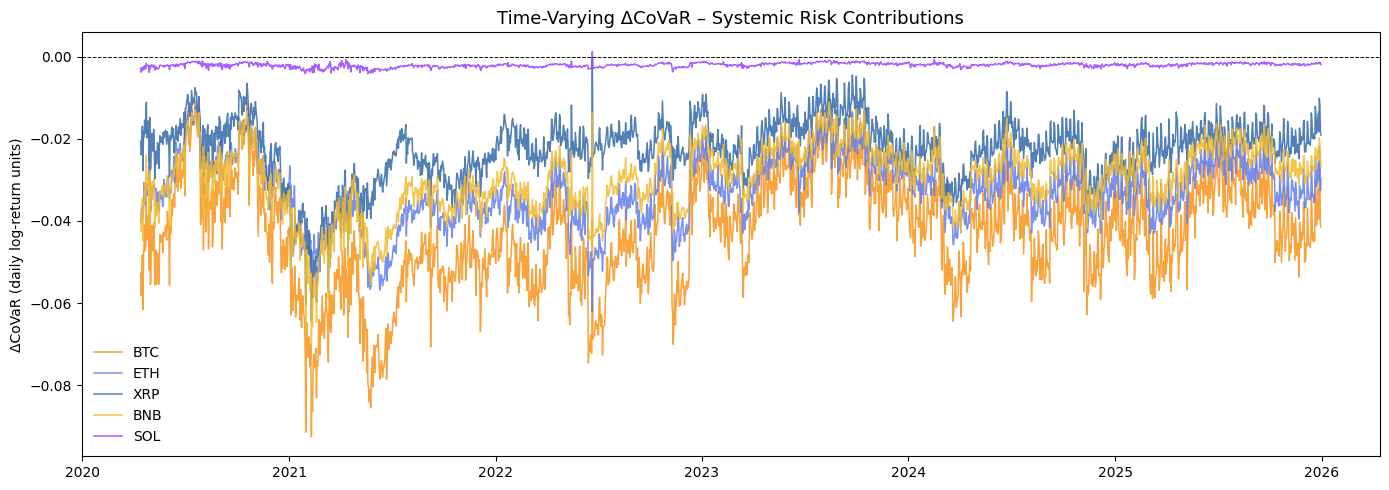

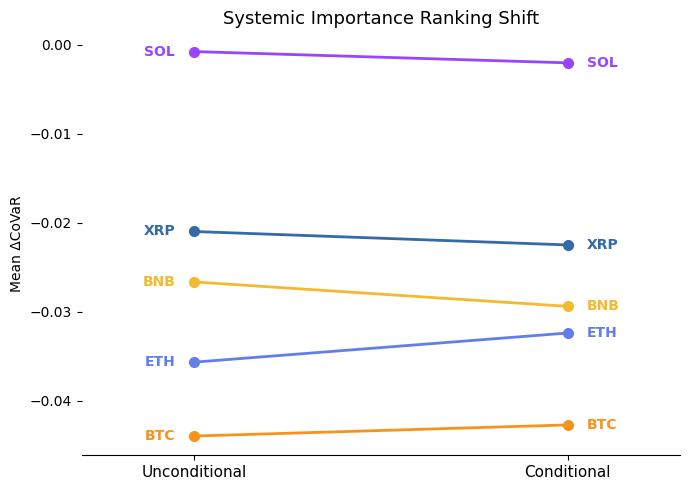

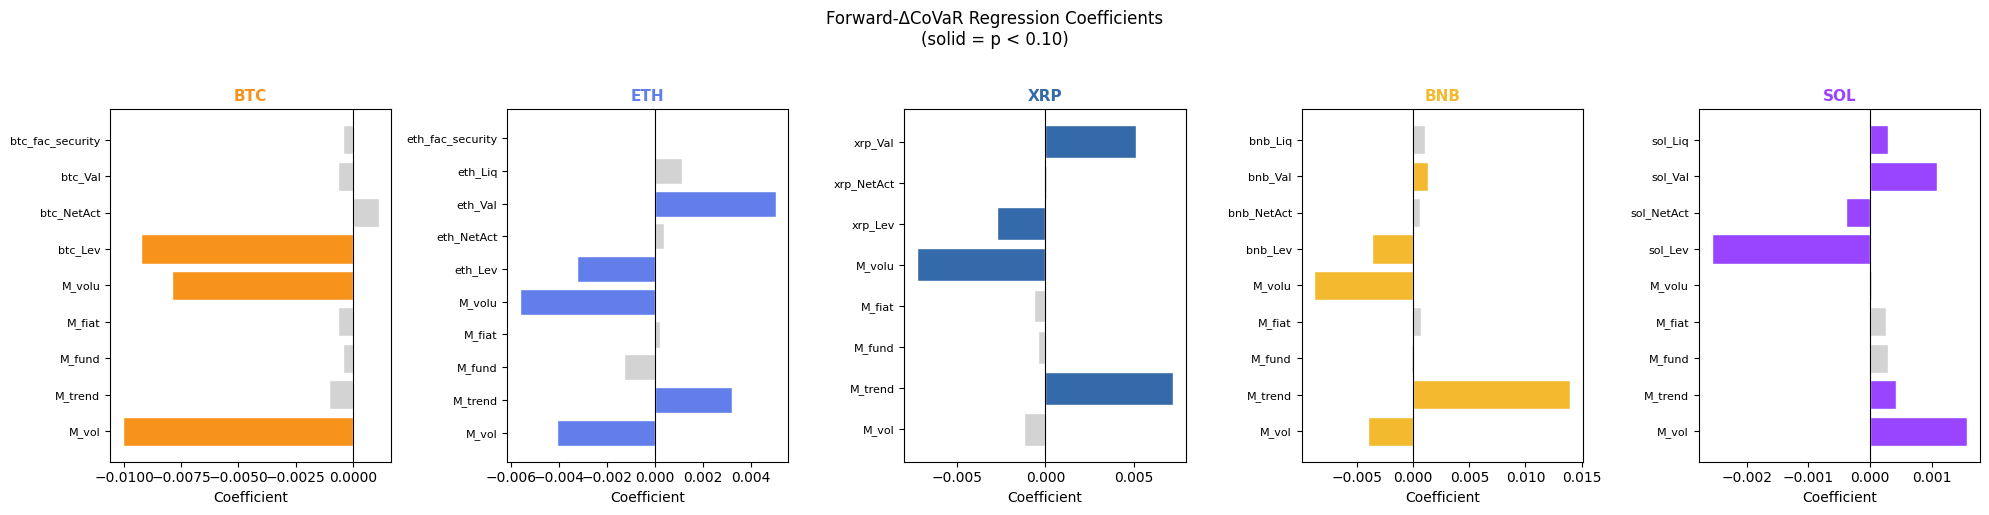

In [44]:
#from covar_engine import run_full_pipeline, print_summary_report
#from covar_engine import plot_dynamic_covar, plot_ranking_shift, plot_feature_importance, plot_forward_covar_fit

# ==========================================================
# AVAILABLE ENGINE PARAMETERS:
# q (float): Tail-risk Quantile (e.g., 0.05 for 5% tail, 0.01 for 1% tail)
# horizon (int): Forward prediction horizon in days (e.g. 1, 5, 10)
# window (int): Rolling window for Delta-CoVaR calculation (Default=100)
# scale_features (bool): True = Z-score standardization
# use_expanding (bool): True = Rolling OOS forecast, False = Static in-sample
# use_quantreg (bool): True = Quantile Regression, False = OLS Replication
# ==========================================================
results = run_full_pipeline(
    full_df, 
    q=0.05, 
    horizon=1, 
    window=100,
    scale_features=True, 
    use_expanding=True,
    use_quantreg=True
)
print_summary_report(results)
plot_dynamic_covar(results)
plot_ranking_shift(results)       # the slope chart for sub-question 1
plot_feature_importance(results)  # which on-chain variables matter most

In [45]:
# Save the fully merged and spliced dataset to your local drive
full_df.to_csv('thesis_full_df_backup_final.csv', index=True)

print("SUCCESS: Master dataframe saved to 'thesis_full_df_backup_final.csv'")
print(f"Final shape of the dataset: {full_df.shape[0]} rows and {full_df.shape[1]} columns")

SUCCESS: Master dataframe saved to 'thesis_full_df_backup_final.csv'
Final shape of the dataset: 2090 rows and 99 columns



  Sensitivity Analysis: BTC
  --> Calculating Conditional CoVaR for q=0.01...
      Running Forward-CoVaR (h=1) | Expanding=False
      Running Forward-CoVaR (h=5) | Expanding=False
      Running Forward-CoVaR (h=10) | Expanding=False
  --> Calculating Conditional CoVaR for q=0.05...
      Running Forward-CoVaR (h=1) | Expanding=False
      Running Forward-CoVaR (h=5) | Expanding=False
      Running Forward-CoVaR (h=10) | Expanding=False
  --> Calculating Conditional CoVaR for q=0.1...
      Running Forward-CoVaR (h=1) | Expanding=False
      Running Forward-CoVaR (h=5) | Expanding=False
      Running Forward-CoVaR (h=10) | Expanding=False

  Sensitivity Analysis: ETH
  --> Calculating Conditional CoVaR for q=0.01...
      Running Forward-CoVaR (h=1) | Expanding=False
      Running Forward-CoVaR (h=5) | Expanding=False
      Running Forward-CoVaR (h=10) | Expanding=False
  --> Calculating Conditional CoVaR for q=0.05...
      Running Forward-CoVaR (h=1) | Expanding=False
      Running

Engine  Pseudo-R2  Pinball_IS  Pinball_OOS
Coin Quantile Horizon                                            
BTC  0.01     1        Static   0.350820    0.000923     0.000762
              5        Static   0.223519    0.001104     0.001452
              10       Static   0.219739    0.001110     0.001677
     0.05     1        Static   0.264702    0.001801     0.002178
              5        Static   0.186017    0.001994     0.002677
              10       Static   0.148963    0.002085     0.003074
     0.10     1        Static   0.273463    0.002383     0.002924
              5        Static   0.188135    0.002662     0.003406
              10       Static   0.145951    0.002801     0.003341
ETH  0.01     1        Static   0.218305    0.000473     0.000871
              5        Static   0.231223    0.000464     0.001041
              10       Static   0.277320    0.000434     0.001060
     0.05     1        Static   0.317174    0.001288     0.003229
              5        Static   0.310070    0.001406     0.004360
              10       Static   0.246286    0.001440     0.005543
     0.10     1        Static   0.316654    0.001678     0.003388
              5        Static   0.249750    0.001836     0.004648
              10       Static   0.224328    0.001920     0.006210
XRP  0.01     1        Static   0.307981    0.000673     0.000828
              5        Static   0.231824    0.000747     0.000682
              10       Static   0.214229    0.000764     0.002684
     0.05     1        Static   0.347404    0.001047     0.001181
              5        Static   0.272552    0.001167     0.001457
              10       Static   0.277296    0.001159     0.001384
     0.10     1        Static   0.315429    0.001363     0.001138
              5        Static   0.213688    0.001566     0.001249
              10       Static   0.182681    0.001628     0.001250
BNB  0.01     1        Static   0.242613    0.000721     0.000797
              5        Static   0.147326    0.000811     0.000865
              10       Static   0.121723    0.000836     0.000814
     0.05     1        Static   0.325474    0.001570     0.001391
              5        Static   0.233291    0.001784     0.001544
              10       Static   0.198049    0.001866     0.001550
     0.10     1        Static   0.350309    0.001798     0.001637
              5        Static   0.258189    0.002053     0.001480
              10       Static   0.215459    0.002171     0.001540
SOL  0.01     1        Static   0.213945    0.000287     0.000271
              5        Static   0.341377    0.000329     0.000314
              10       Static   0.139625    0.000331     0.000396
     0.05     1        Static   0.193254    0.000478     0.001137
              5        Static   0.212811    0.000470     0.001099
              10       Static   0.136544    0.000483     0.001040
     0.10     1        Static   0.195441    0.000413     0.000616
              5        Static   0.145541    0.000425     0.000549
              10       Static   0.161521    0.000405     0.000635

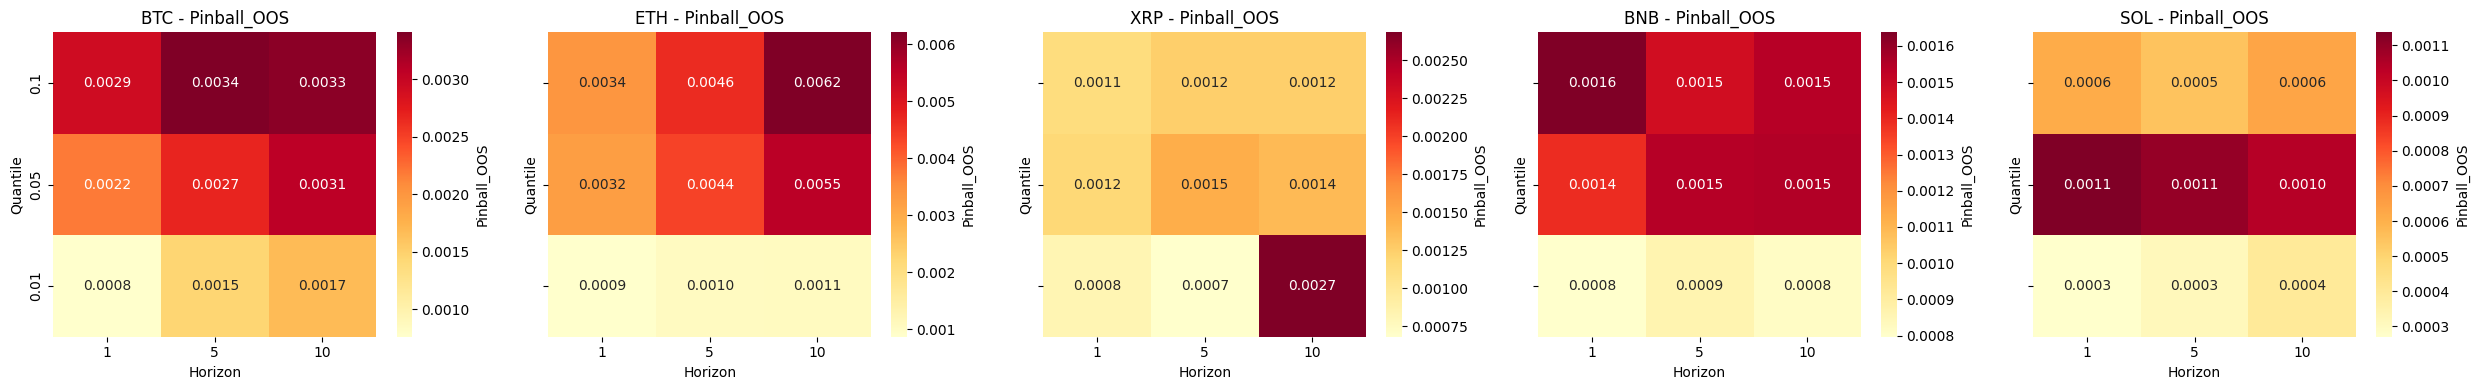

In [46]:
# 1. Run the sensitivity grid (Default uses the FASTER, static engine)
# This will test horizons 1, 5, 10 and quantiles 1%, 5%, 10%
# ==========================================================
# AVAILABLE SENSITIVITY PARAMETERS:
# quantiles (list): Tail-risk Quantiles to sweep (e.g., [0.01, 0.05])
# horizons (list): Forward prediction horizons (e.g. [1, 5, 10])
# scale_features (bool): True = Z-score standardization
# use_expanding (bool): True = Rolling OOS forecast, False = Static in-sample
# use_quantreg (bool): True = Quantile Regression, False = OLS Replication
# ==========================================================
sens_df = run_sensitivity_analysis(
    full_df, 
    quantiles=[0.01, 0.05, 0.10], 
    horizons=[1, 5, 10], 
    window=100,
    scale_features=True, 
    use_expanding=False, # Set to True for the full rigorous 40-minute matrix!
    use_quantreg=True
)

# 2. View the raw Pandas MultiIndex table
display(sens_df)

# 3. Plot the final heatmap (e.g. Pinball Loss or Pseudo-R2)
plot_sensitivity_heatmap(sens_df, metric='Loss_OOS')



  Sensitivity Analysis: BTC
  --> Calculating Conditional CoVaR for q=0.01...
      Running Forward-CoVaR (h=1) | Expanding=True
      Running Forward-CoVaR (h=5) | Expanding=True
      Running Forward-CoVaR (h=10) | Expanding=True
  --> Calculating Conditional CoVaR for q=0.05...
      Running Forward-CoVaR (h=1) | Expanding=True
      Running Forward-CoVaR (h=5) | Expanding=True
      Running Forward-CoVaR (h=10) | Expanding=True
  --> Calculating Conditional CoVaR for q=0.1...
      Running Forward-CoVaR (h=1) | Expanding=True
      Running Forward-CoVaR (h=5) | Expanding=True
      Running Forward-CoVaR (h=10) | Expanding=True

  Sensitivity Analysis: ETH
  --> Calculating Conditional CoVaR for q=0.01...
      Running Forward-CoVaR (h=1) | Expanding=True
      Running Forward-CoVaR (h=5) | Expanding=True
      Running Forward-CoVaR (h=10) | Expanding=True
  --> Calculating Conditional CoVaR for q=0.05...
      Running Forward-CoVaR (h=1) | Expanding=True
      Running Forward-CoVa

Engine  Pseudo-R2  Pinball_IS  Pinball_OOS
Coin Quantile Horizon                                               
BTC  0.01     1        Expanding   0.351877    0.000852     0.001201
              5        Expanding   0.195191    0.001058     0.001273
              10       Expanding   0.145737    0.001123     0.001383
     0.05     1        Expanding   0.233981    0.001777     0.001915
              5        Expanding   0.149091    0.001974     0.002148
              10       Expanding   0.087272    0.002117     0.002347
     0.10     1        Expanding   0.248264    0.002344     0.002566
              5        Expanding   0.154299    0.002637     0.002891
              10       Expanding   0.108886    0.002779     0.003077
ETH  0.01     1        Expanding   0.251353    0.000451     0.000494
              5        Expanding   0.252725    0.000450     0.000508
              10       Expanding   0.258575    0.000445     0.000515
     0.05     1        Expanding   0.335523    0.001223     0.001266
              5        Expanding   0.303349    0.001372     0.001417
              10       Expanding   0.218196    0.001463     0.001554
     0.10     1        Expanding   0.336902    0.001595     0.001596
              5        Expanding   0.271710    0.001754     0.001786
              10       Expanding   0.272033    0.001841     0.001881
XRP  0.01     1        Expanding   0.306023    0.000631     0.000831
              5        Expanding   0.269150    0.000665     0.000862
              10       Expanding   0.259676    0.000674     0.000859
     0.05     1        Expanding   0.313386    0.001018     0.001183
              5        Expanding   0.238189    0.001129     0.001324
              10       Expanding   0.250355    0.001111     0.001298
     0.10     1        Expanding   0.339833    0.001297     0.001316
              5        Expanding   0.255646    0.001463     0.001552
              10       Expanding   0.232336    0.001509     0.001637
BNB  0.01     1        Expanding   0.206704    0.000731     0.001000
              5        Expanding   0.135953    0.000796     0.001014
              10       Expanding   0.121992    0.000809     0.001072
     0.05     1        Expanding   0.317898    0.001494     0.001774
              5        Expanding   0.236224    0.001673     0.001950
              10       Expanding   0.205673    0.001740     0.002056
     0.10     1        Expanding   0.334478    0.001695     0.001892
              5        Expanding   0.264788    0.001873     0.002090
              10       Expanding   0.229058    0.001964     0.002175
SOL  0.01     1        Expanding   0.295036    0.000280     0.000329
              5        Expanding   0.207071    0.000315     0.000397
              10       Expanding   0.056198    0.000326     0.000419
     0.05     1        Expanding   0.176453    0.000506     0.000546
              5        Expanding   0.155896    0.000502     0.000544
              10       Expanding   0.087711    0.000509     0.000558
     0.10     1        Expanding   0.068049    0.000401     0.000519
              5        Expanding   0.200259    0.000406     0.000522
              10       Expanding   0.216781    0.000402     0.000522

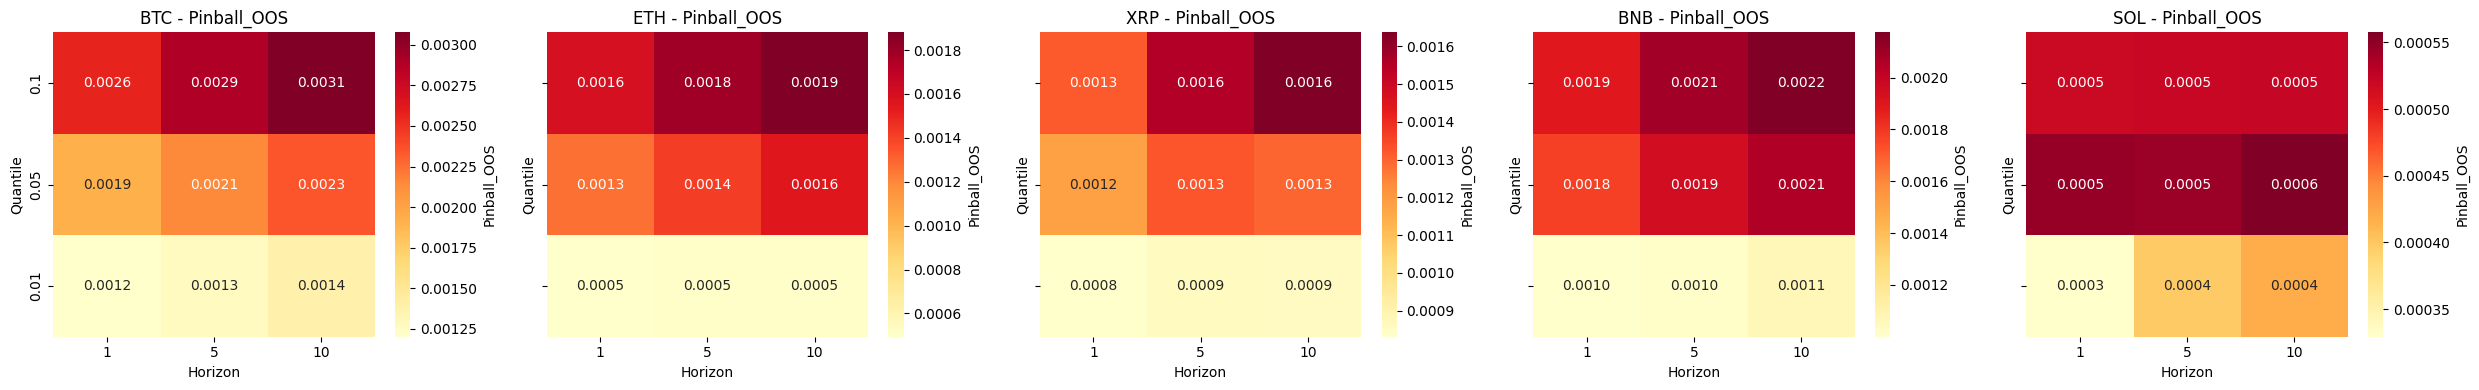

In [47]:
# 1. Run the sensitivity grid (Expanding window engine)
# This will test horizons 1, 5, 10 and quantiles 1%, 5%, 10%
# ==========================================================
# AVAILABLE SENSITIVITY PARAMETERS:
# quantiles (list): Tail-risk Quantiles to sweep (e.g., [0.01, 0.05])
# horizons (list): Forward prediction horizons (e.g. [1, 5, 10])
# scale_features (bool): True = Z-score standardization
# use_expanding (bool): True = Rolling OOS forecast, False = Static in-sample
# use_quantreg (bool): True = Quantile Regression, False = OLS Replication
# ==========================================================
sens_df = run_sensitivity_analysis(
    full_df, 
    quantiles=[0.01, 0.05, 0.10], 
    horizons=[1, 5, 10], 
    window=100,
    scale_features=True, 
    use_expanding=True, # Triggers rigorous 40-minute matrix
    use_quantreg=True
)

# 2. View the raw Pandas MultiIndex table
display(sens_df)

# 3. Plot the final heatmap (e.g. Pinball Loss or Pseudo-R2)
plot_sensitivity_heatmap(sens_df, metric='Loss_OOS')
